In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
plt.rcParams["font.family"] = "Arial"  # Set global font to Arial

### fit with percentage, with fixed A/B but unfixed A + B

In [2]:
from scipy.optimize import curve_fit

def adsorption_ratio2(x, f, k):
    """
    Model:  (f * k * x) / (1 + (1-f)* k * x)

    Parameters
    ----------
    x : array‑like
        Independent variable (e.g., R_sol or concentration).
    f, k : float
        Fit parameters:
        f – fraction of accessible sites (dimensionless)
        k – equilibrium constant

    Returns
    -------
    y : ndarray
        Model prediction at each x.
    """
    x = np.asarray(x, dtype=float)
    return (f * k * x) / (1 + (1-f)* k * x)
 
def fit_adsorption_ratio2(xdata, ydata, p0=(0.5, 1.0)):
    """
    Returns
    -------
    popt : ndarray  -- best‑fit [A, B, k]
    pcov : ndarray  -- parameter covariance matrix
    """
    x = np.asarray(xdata, dtype=float)
    y = np.asarray(ydata, dtype=float)

    # keep only finite pairs
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        raise ValueError("Not enough finite points to perform the fit.")

    popt, pcov = curve_fit(
        adsorption_ratio2,
        x[mask],
        y[mask],
        p0=p0,
        maxfev=5000
    )
    return popt, pcov


In [3]:
df = pd.read_csv("mof-808.csv", delimiter = ',')
unique_acid = df["Acid"].unique()

BA
BA


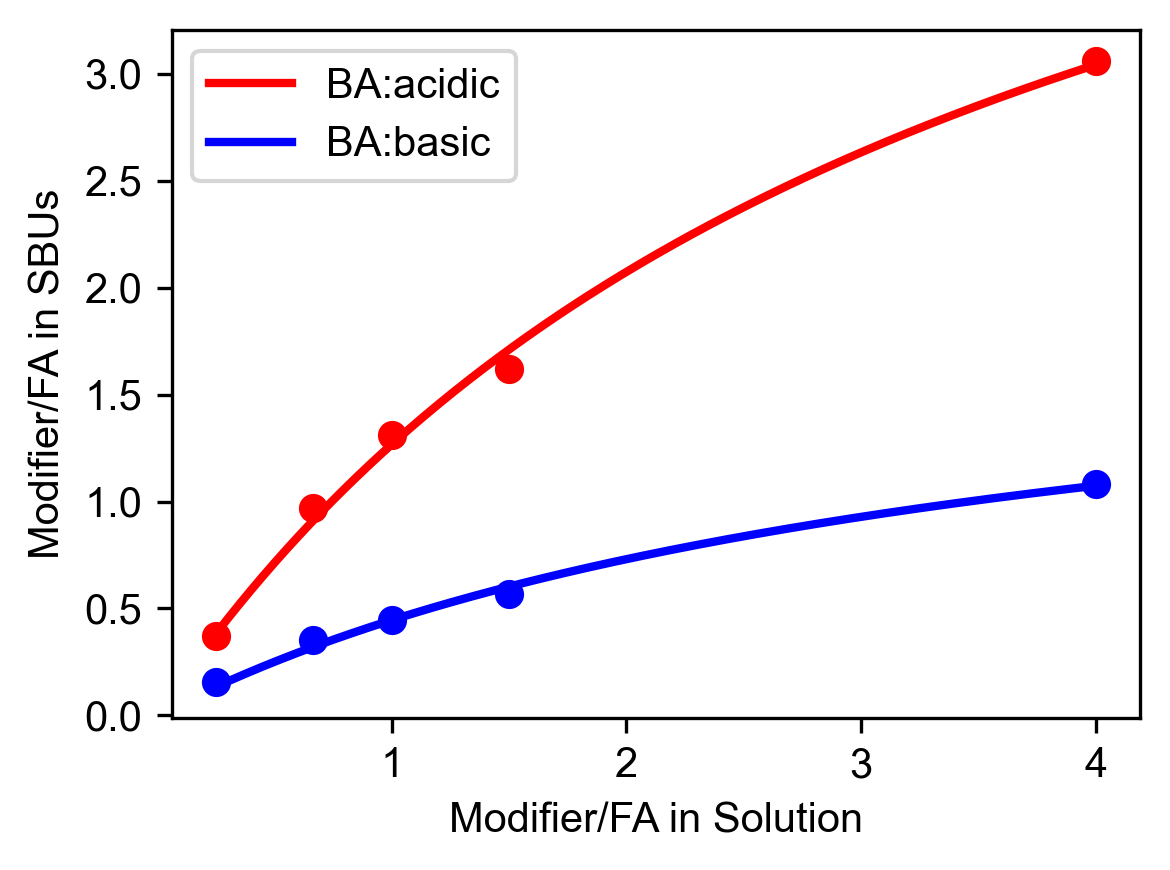

HAc
HAc


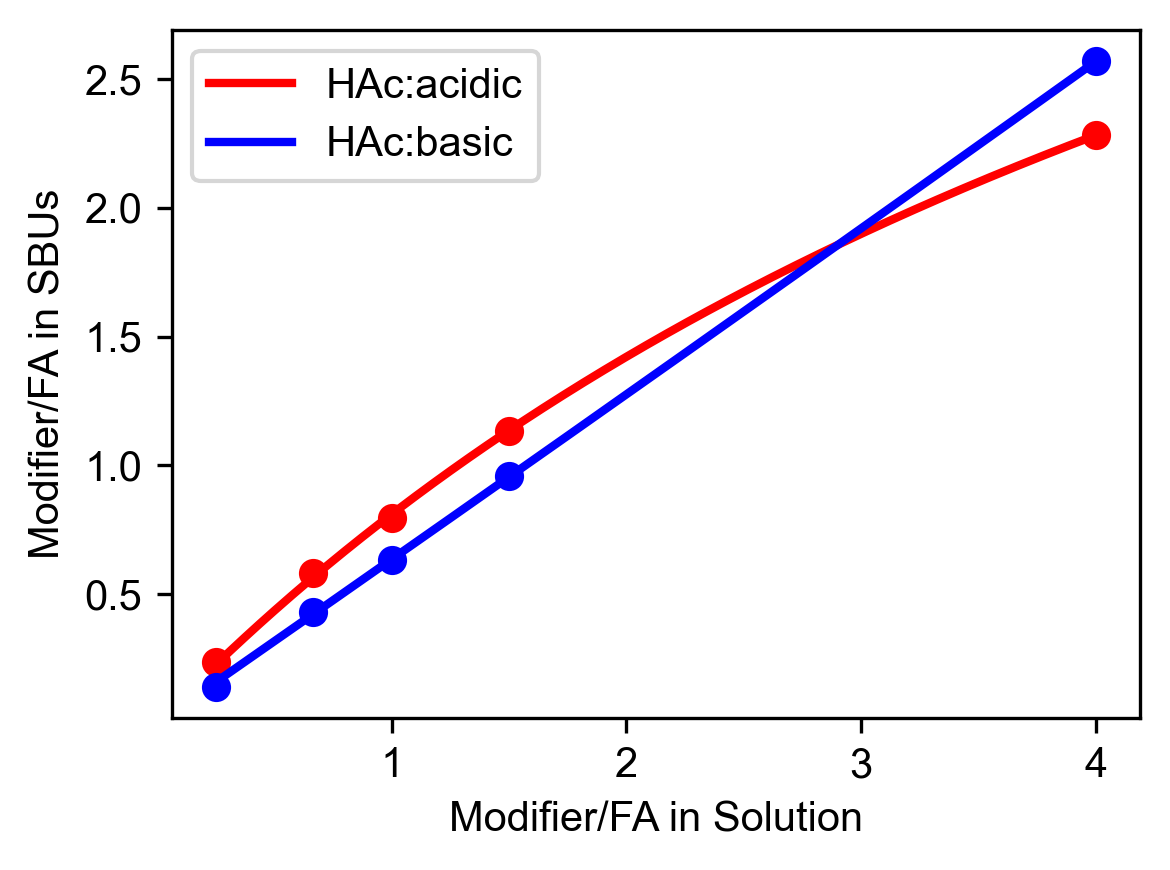

GA
GA


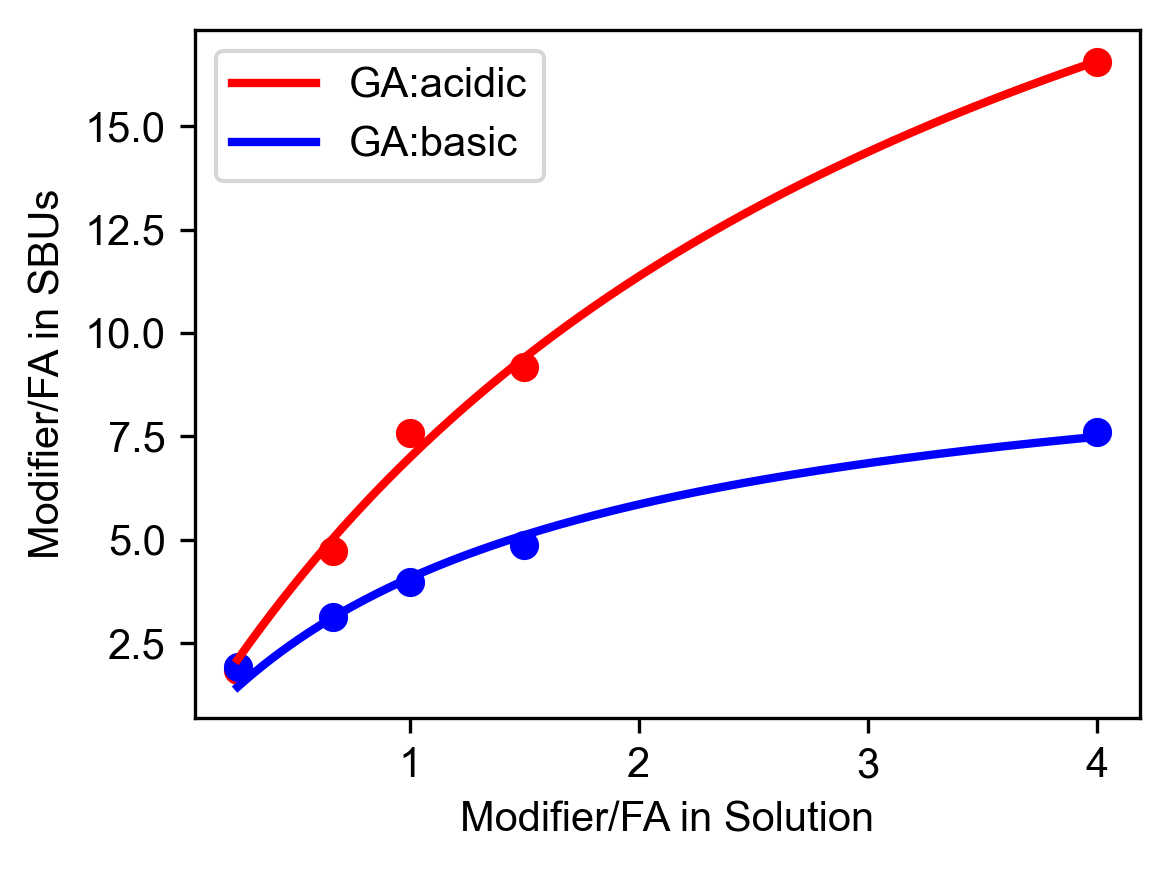

SA
SA


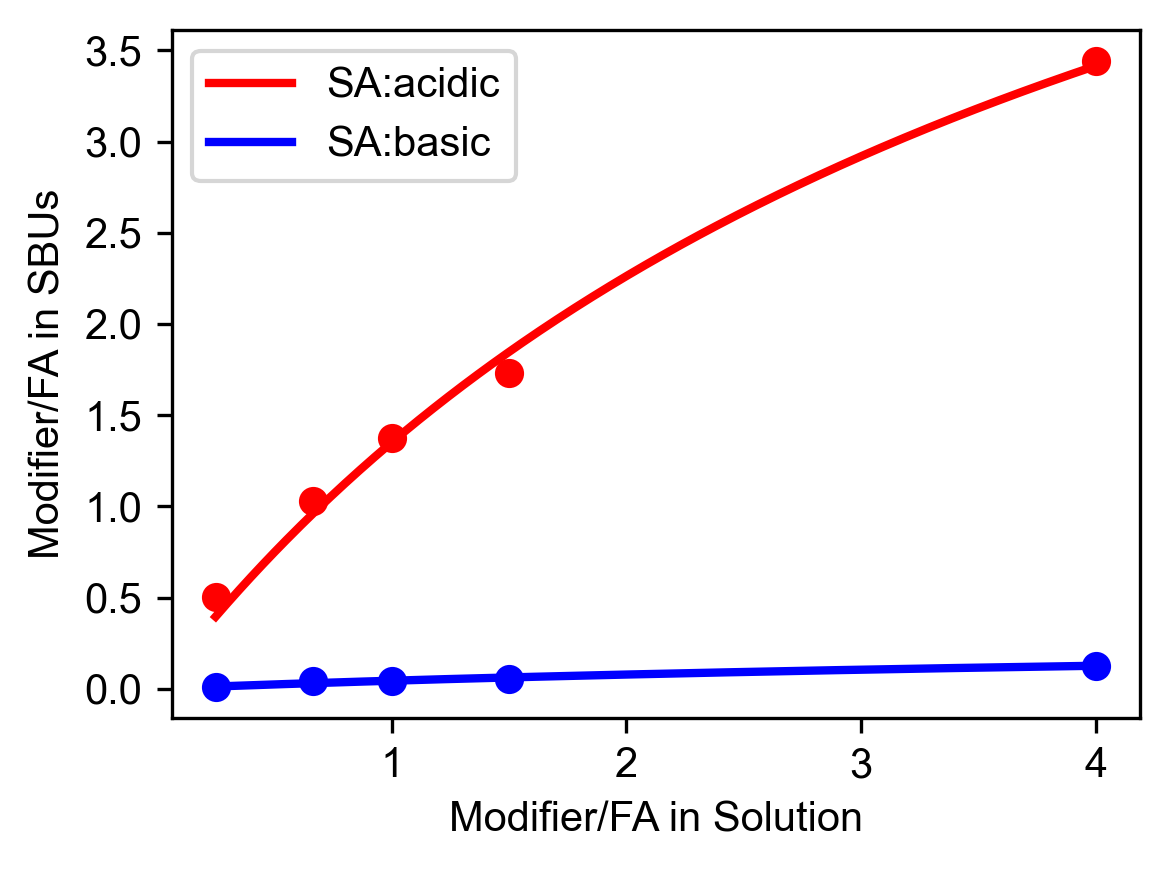

FBA
FBA


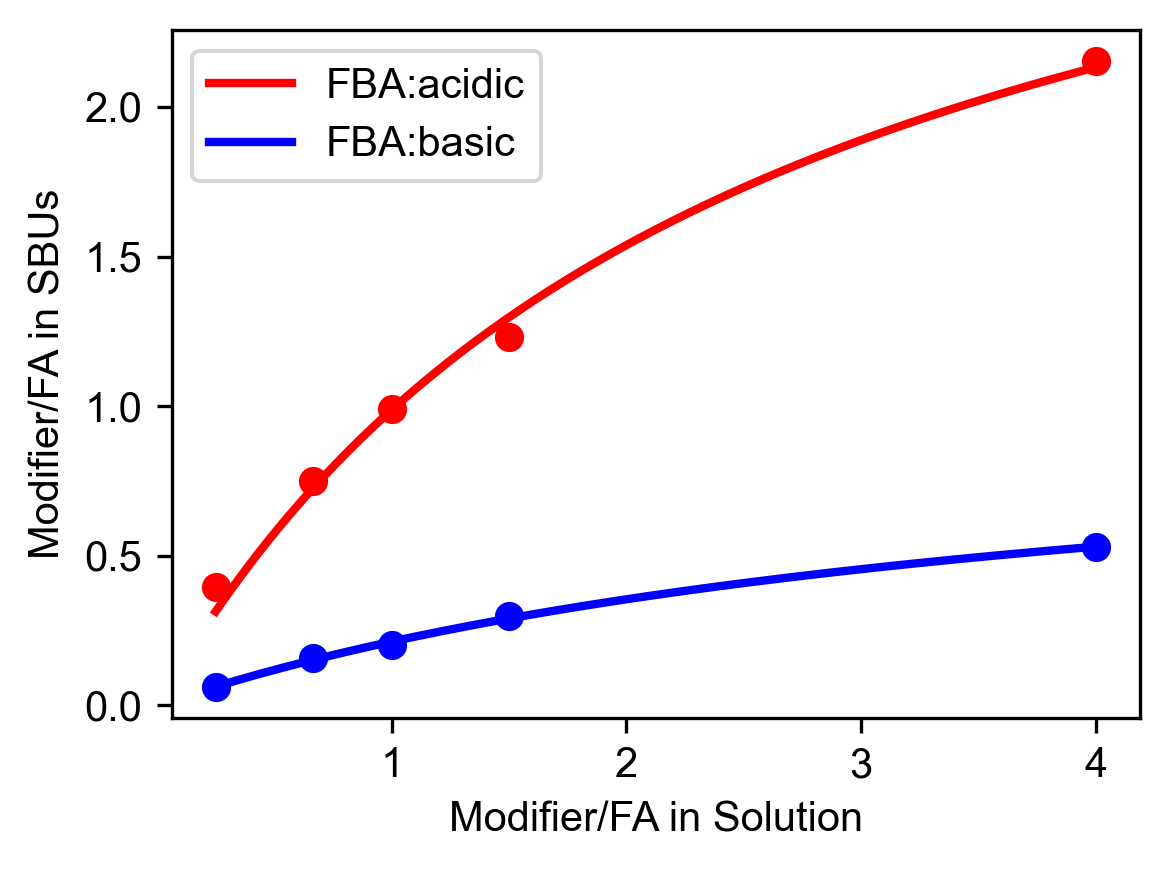

In [4]:
summary = []
color = ["red", "blue"]

for acid_temp in unique_acid:
    df_by_acid = df.loc[df["Acid"] == acid_temp]
    
    plt.rcParams['font.family'] = 'Arial'
    fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)

    count = 0 
    for experiment_type in df_by_acid["Experiment"].unique():
        
        try:
            print(acid_temp)
            this_curve = df_by_acid.loc[df_by_acid["Experiment"] == experiment_type]
            
            x = this_curve["Acid conc (mM)"]/this_curve["FA conc (mM)"]
            y = this_curve["acid/SBU"]/this_curve["FA/SBU"]

            popt = fit_adsorption_ratio2(x.values,y.values)[0]
            A = (this_curve["acid/SBU"] + this_curve["FA/SBU"])*popt[0]
            B = (this_curve["acid/SBU"] + this_curve["FA/SBU"])*(1 - popt[0])
            
            # Generate smooth curve for plotting
            x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 300)
            y_fit = adsorption_ratio2(x_fit, *popt)

            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "A": np.around(A.values, 2),
                "mean_A": np.around(A.values.mean(), 2),
                "std_A": np.around(A.values.std(), 2),
                
                "B": np.around(B.values, 2),
                "mean_B": np.around(B.values.mean(), 2),
                "std_B": np.around(B.values.std(), 2),
                
                "percentage": popt[0], #f: fraction of accessible sites
                "k": popt[1] #k: equilibrium constant
            })


            # -----------------------------
            # 4.  Plot
            # -----------------------------
            ax.plot(x_fit, y_fit, linewidth=2, label= acid_temp + ":" + experiment_type, c = color[count])
            ax.scatter(x, y, c = color[count])
            ax.set_xlabel(f'Modifier/FA in Solution')
            ax.set_ylabel(f'Modifier/FA in SBUs')
            ax.legend(loc='upper left')
            count = count + 1 
        except:
            print(acid_temp, experiment_type)
            count = count + 1
            
    plt.tight_layout()
    plt.show()
summary1 = pd.DataFrame(summary)

In [5]:
display(summary1)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,BA,acidic,"[3.52, 3.52, 3.66, 3.56, 3.34]",3.52,0.10,"[0.62, 0.62, 0.64, 0.62, 0.58]",0.62,0.02,0.850999,1.913558
1,BA,basic,"[3.74, 3.7, 4.0, 4.18, 4.07]",3.94,0.19,"[1.84, 1.82, 1.98, 2.06, 2.01]",1.94,0.09,0.669594,0.853338
2,HAc,acidic,"[3.75, 3.78, 3.79, 3.7, 3.8]",3.77,0.04,"[0.65, 0.66, 0.66, 0.64, 0.66]",0.65,0.01,0.852414,1.106587
3,HAc,basic,"[5.74, 5.75, 5.84, 5.81, 6.28]",5.88,0.20,"[-0.03, -0.03, -0.03, -0.03, -0.03]",-0.03,0.00,1.005179,0.630619
4,GA,acidic,"[5.44, 5.33, 5.15, 5.1, 4.69]",5.14,0.26,"[0.18, 0.17, 0.17, 0.17, 0.15]",0.17,0.01,0.968311,9.343682
5,GA,basic,"[6.29, 6.2, 6.18, 6.26, 6.13]",6.21,0.05,"[0.6, 0.6, 0.6, 0.6, 0.59]",0.60,0.01,0.912209,7.350028
6,SA,acidic,"[3.88, 3.87, 3.9, 3.87, 3.92]",3.89,0.02,"[0.56, 0.55, 0.56, 0.55, 0.56]",0.56,0.00,0.874442,1.916102
7,SA,basic,"[1.37, 1.42, 1.44, 0.74, 1.48]",1.29,0.28,"[4.13, 4.3, 4.36, 2.24, 4.48]",3.90,0.84,0.248276,0.205040
8,FBA,acidic,"[3.53, 3.46, 3.53, 3.48, 3.4]",3.48,0.05,"[1.01, 1.0, 1.01, 1.0, 0.98]",1.00,0.01,0.776584,1.777110
9,FBA,basic,"[2.87, 2.86, 2.92, 2.94, 3.16]",2.95,0.11,"[2.73, 2.72, 2.78, 2.8, 3.0]",2.80,0.10,0.512818,0.521948


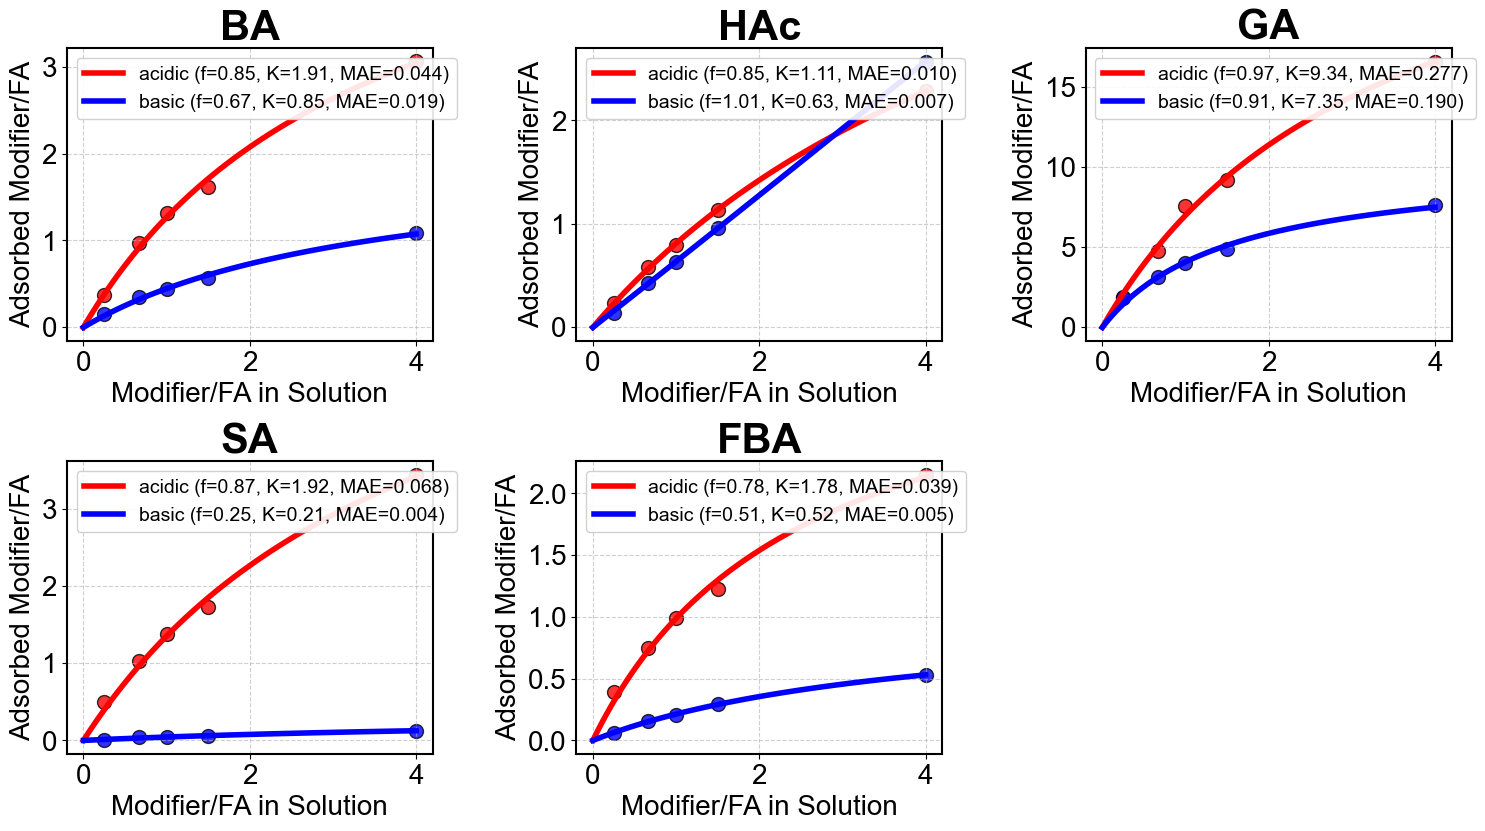

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Create a figure with a more compact layout - using less width for the subplots
fig = plt.figure(figsize=(30, 16))
# Create a grid with 4 rows and 6 columns, but only use the left half for these plots
# This leaves the right half of the figure available for other plots
gs = GridSpec(4, 6, figure=fig)


# Define color scheme for experiment types
experiment_colors = {'acidic': 'red', 'basic': 'blue'}
acids = df[df['Acid'] != 'CA']['Acid'].unique()
# Font sizes for publication-quality appearance
TITLE_SIZE = 30
LABEL_SIZE = 20
TICK_SIZE = 20
LEGEND_SIZE = 14

# Function to plot individual acid data
def plot_acid_data(ax, acid_name):
    acid_data = summary1[summary1['Acid'] == acid_name]
    
    for idx, row in acid_data.iterrows():
        experiment_type = row['Experiment']
        f = row['percentage']   # fraction of accessible sites
        k = row['k']            # equilibrium constant
        
        # Generate fitting curve
        x_fit = np.linspace(0, 4., 100)
        y_fit = adsorption_ratio2(x_fit, f, k)
        
        # Experimental data
        acid_df = df[(df['Acid'] == acid_name) & (df['Experiment'] == experiment_type)]
        x_points = acid_df['Acid conc (mM)'].values / acid_df['FA conc (mM)'].values
        y_points = acid_df['acid/SBU'].values / acid_df['FA/SBU'].values
        
        # Interpolate fitted values at experimental points
        y_pred = np.interp(x_points, x_fit, y_fit)
        
        # ---- Compute MAE ----
        mae = np.mean(np.abs(y_points - y_pred))
        
        # ---- Plot ----
        ax.plot(x_fit, y_fit, linewidth=4,
                label=f"{experiment_type} (f={f:.2f}, K={k:.2f}, MAE={mae:.3f})",
                color=experiment_colors[experiment_type])
        ax.scatter(x_points, y_points, color=experiment_colors[experiment_type],
                   alpha=0.8, s=100, edgecolors='black', linewidths=1)
    
    # ---- Styling ----
    ax.set_title(f"{acid_name}", fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Modifier/FA in Solution', fontsize=LABEL_SIZE)
    ax.set_ylabel('Adsorbed Modifier/FA', fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Border enhancement
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# Plot each acid in its own subplot
for i, acid in enumerate(acids[:12]):  # Limit to 12 acids to fit in the grid
    row = i // 3
    col = i % 3
    # Use only the left half of the grid (columns 0, 1, 2)
    ax = fig.add_subplot(gs[row, col])
    plot_acid_data(ax, acid)

plt.tight_layout()
plt.show()


2. Fit the two independent curves

In [7]:
import numpy as np
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# vectorised model for BOTH curves
# ----------------------------------------------------------------------
def _two_curve_model(xcat, n1, A, B, k):
    """
    xcat : concatenated x-data  (len = n1 + n2)
    n1   : length of first data block
    A, B, k : shared parameters
    """
    x1, x2 = xcat[:n1], xcat[n1:]

    ycat = np.empty_like(xcat, dtype=float)
    ycat[:n1]  = A / (k * x1 + 1) + B               # curve 1
    ycat[n1:]  = (k * x2 / (k * x2 + 1)) * A        # curve 2
    return ycat

# ----------------------------------------------------------------------
# public helper
# ----------------------------------------------------------------------
def fit_two_curves_shared(x1, y1, x2, y2, p0=(1., 0., 1.),
                          bounds=([0., 0., 0.], [np.inf, np.inf, np.inf])):
    """
    Simultaneous least‑squares fit with shared (A, B, k).

    Parameters
    ----------
    x1, y1 : 1‑D array‑like     data for curve 1
    x2, y2 : 1‑D array‑like     data for curve 2
    p0     : tuple              initial (A, B, k)
    bounds : 2‑tuple/list       ([Amin, Bmin, kmin], [Amax, Bmax, kmax])

    Returns
    -------
    popt : ndarray   best‑fit [A, B, k]
    pcov : ndarray   covariance matrix
    """

    # ­­­­­‑‑ clean NaN / Inf
    m1 = np.isfinite(x1) & np.isfinite(y1)
    m2 = np.isfinite(x2) & np.isfinite(y2)
    if m1.sum() + m2.sum() < 3:
        raise ValueError("Need at least three finite points total.")

    x1c, y1c = np.asarray(x1)[m1], np.asarray(y1)[m1]
    x2c, y2c = np.asarray(x2)[m2], np.asarray(y2)[m2]

    # ­­­­­‑‑ concatenate
    xcat  = np.concatenate([x1c,  x2c])
    ycat  = np.concatenate([y1c,  y2c])
    n1    = len(x1c)            # border index for the model

    # ­­­­­‑‑ wrapper with fixed n1 for curve_fit
    model = lambda x, A, B, k: _two_curve_model(x, n1, A, B, k)

    popt, pcov = curve_fit(model, xcat, ycat, p0=p0,
                           bounds=bounds, maxfev=5000)
    return popt, pcov


In [8]:
popt, pcov = fit_two_curves_shared(x, this_curve["FA/SBU"].values, x, this_curve["acid/SBU"].values,
                                   p0=(2., 0.5, 10.),
                                   bounds=([0, 0, 0], [12, 12, np.inf]))
print("A, B, k  =", popt)

A, B, k  = [3.12436321 2.66809662 0.48551651]


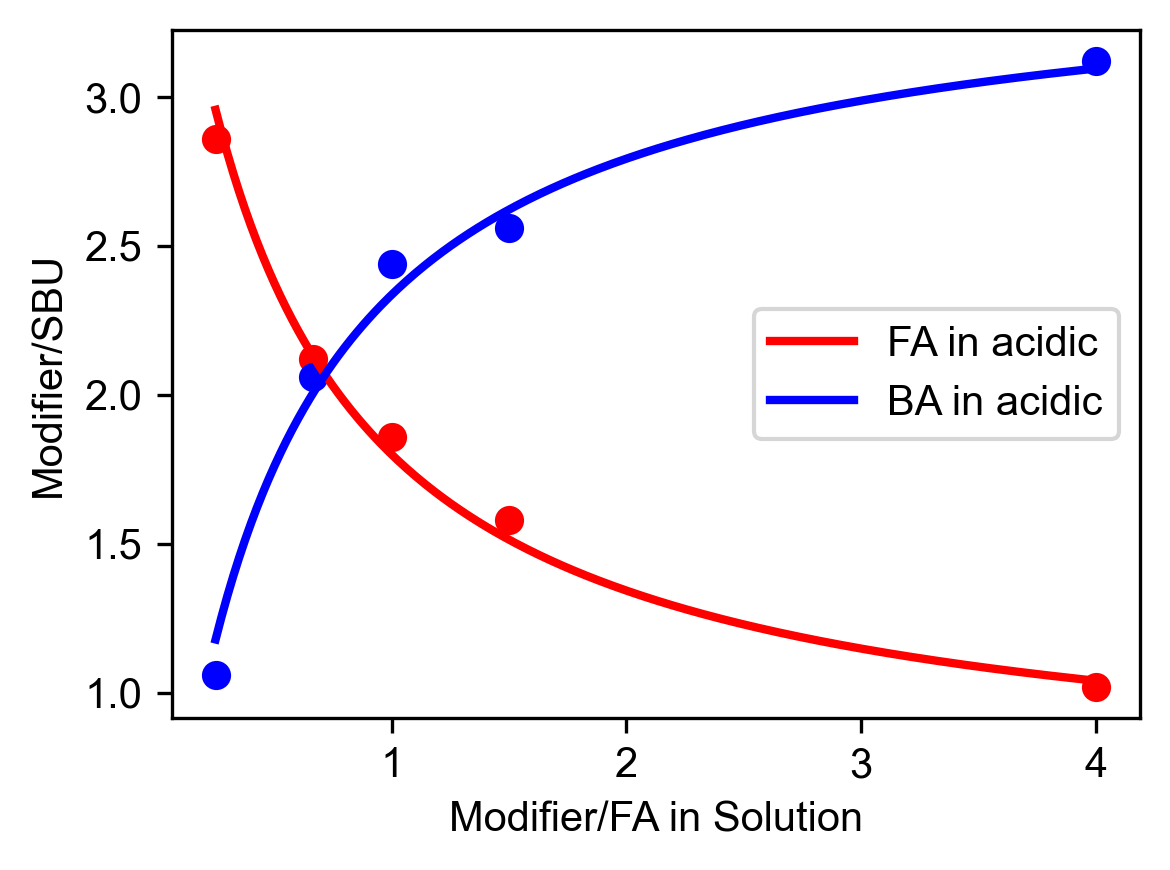

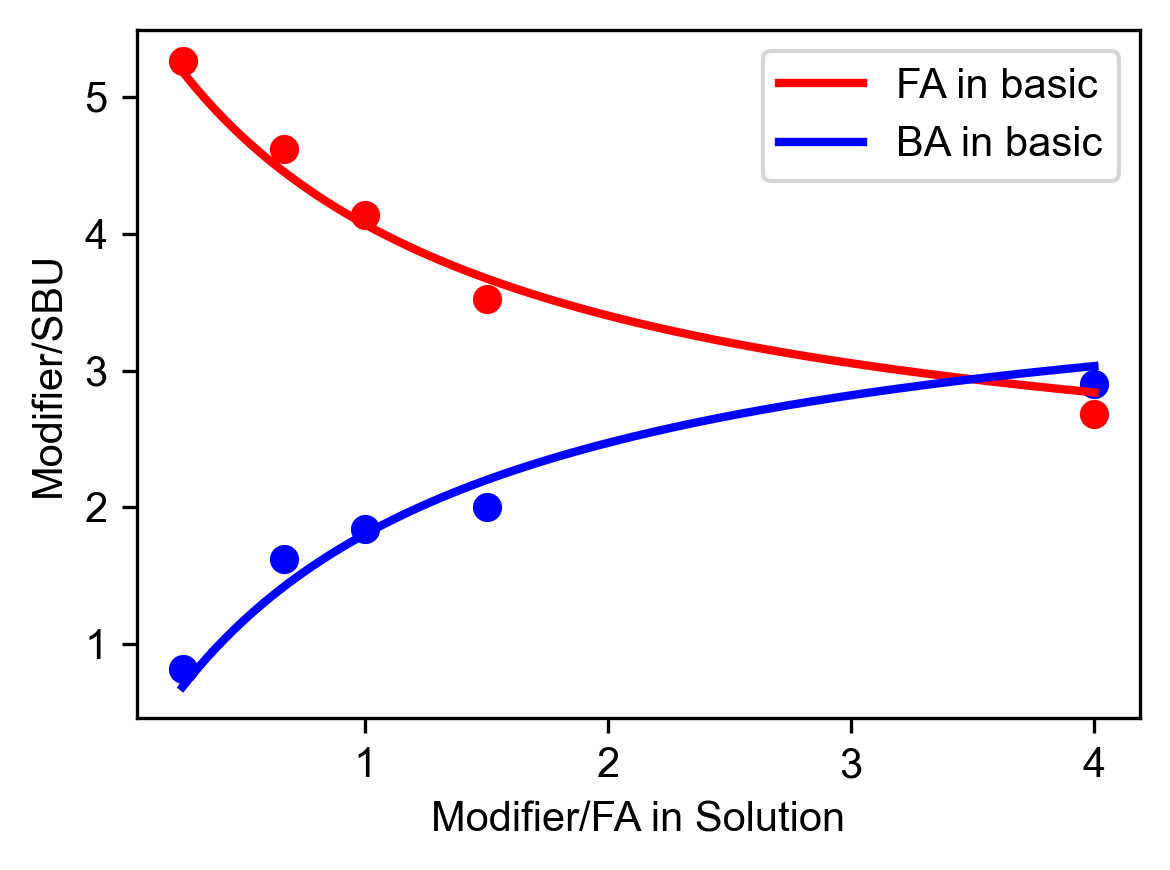

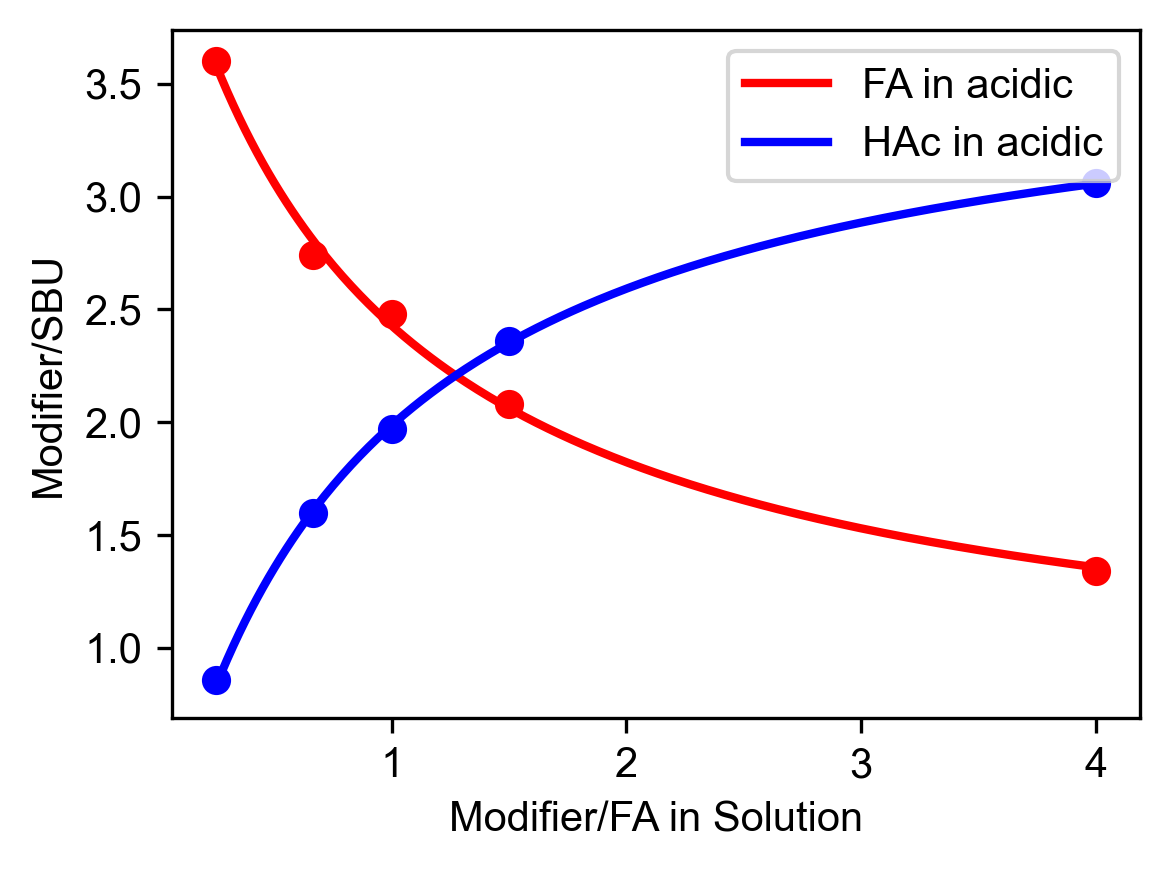

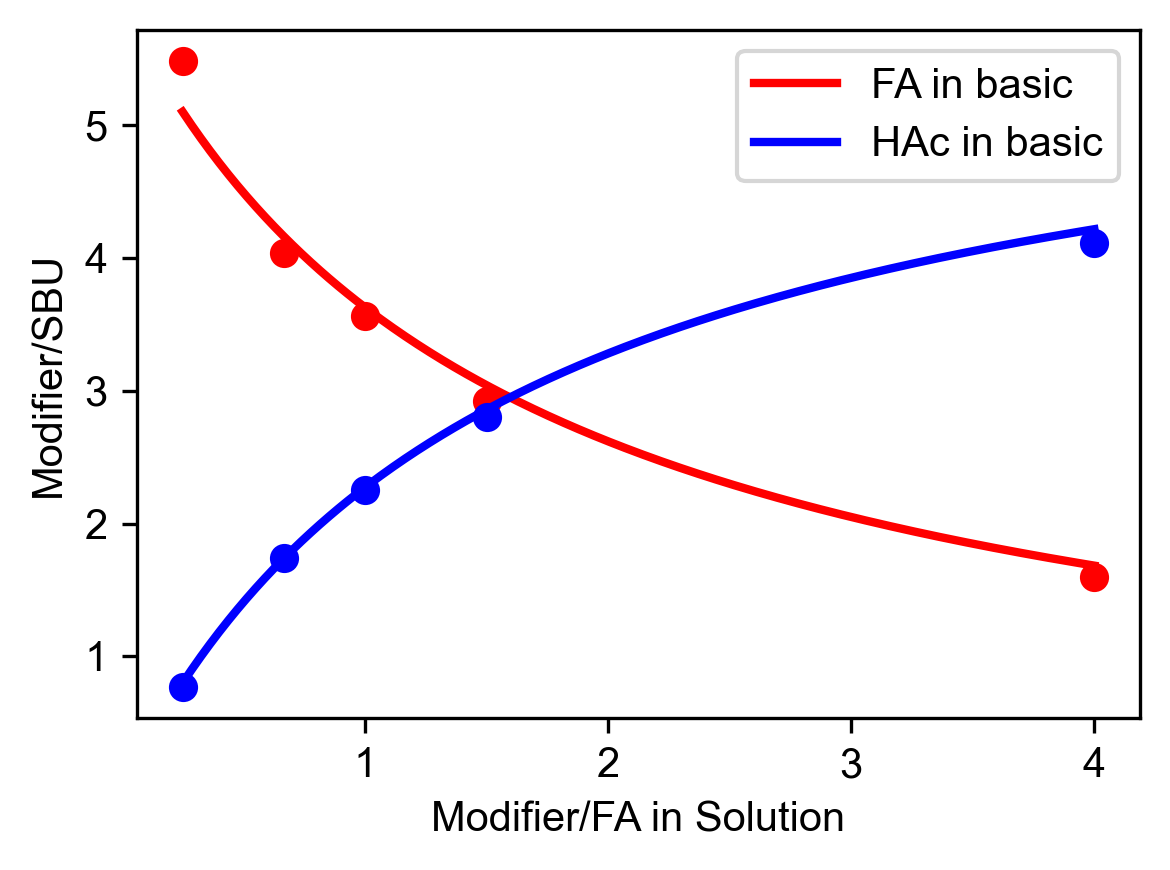

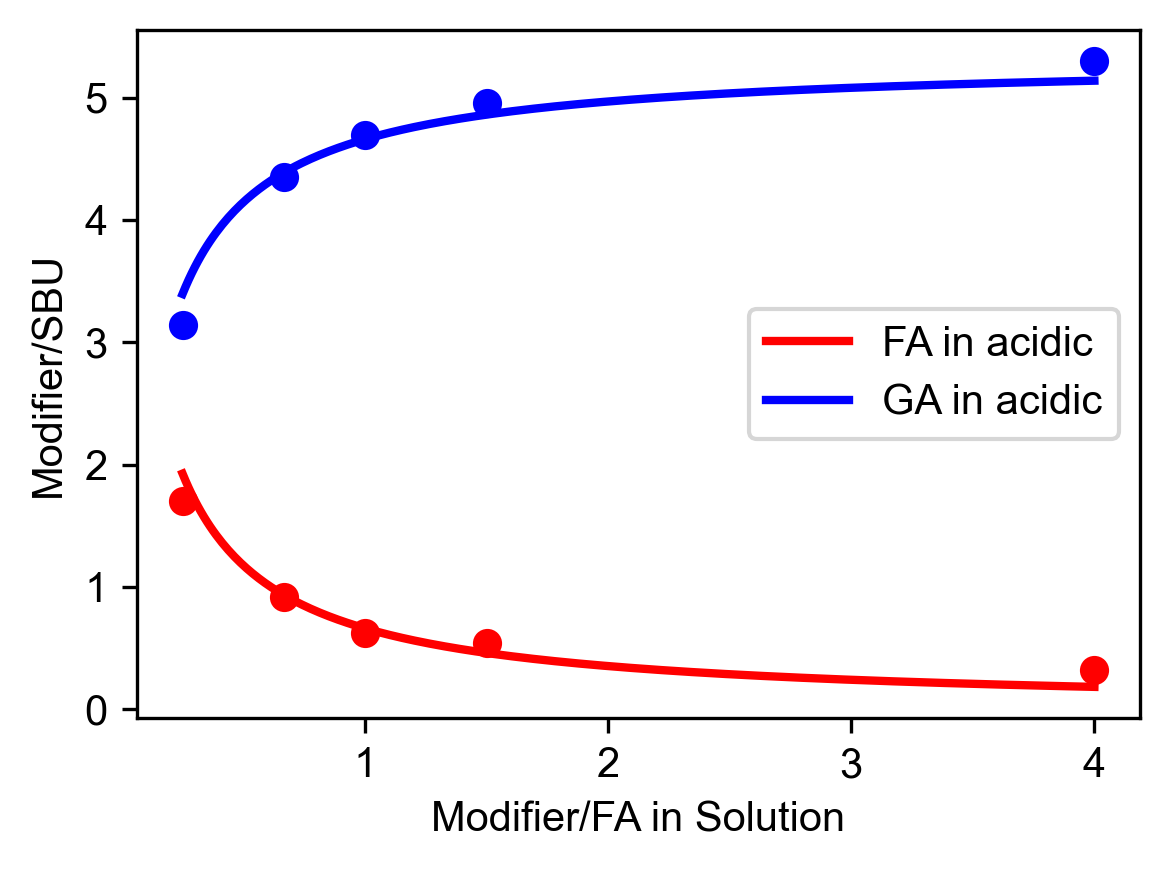

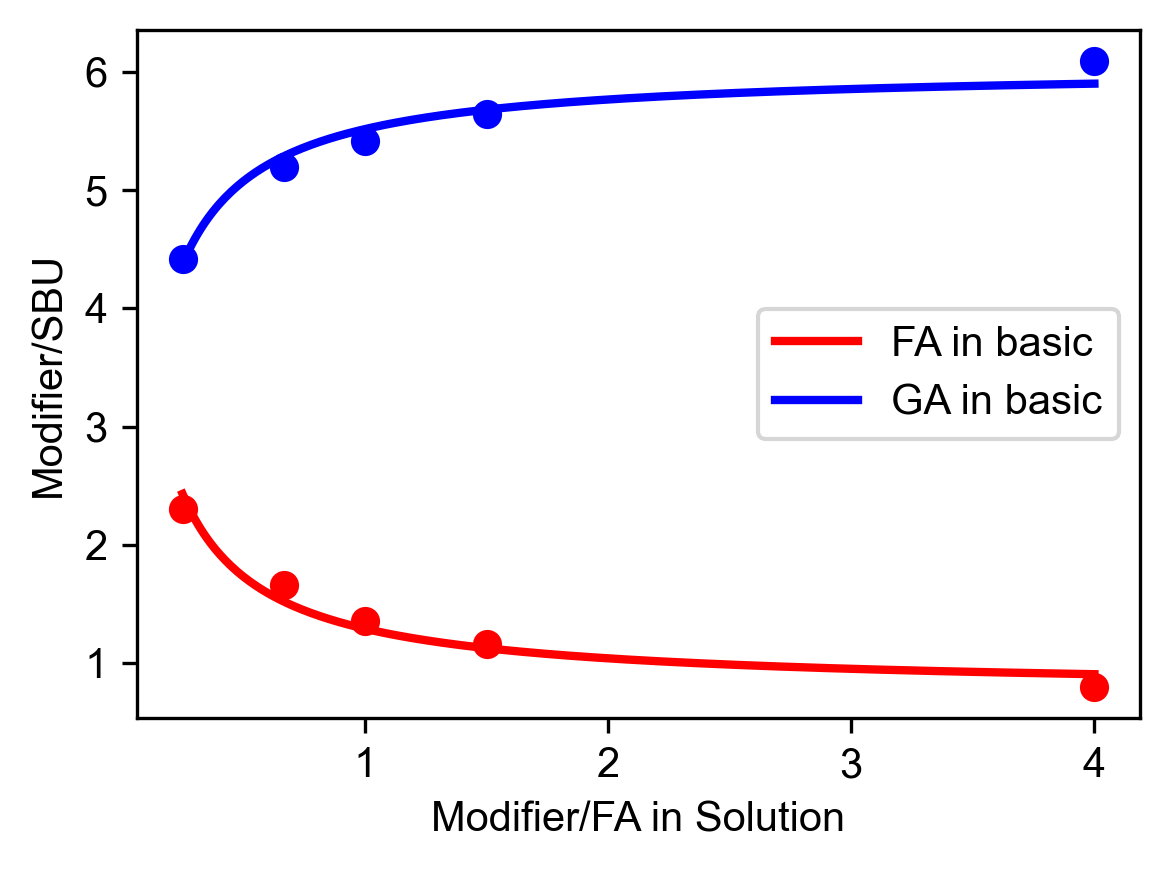

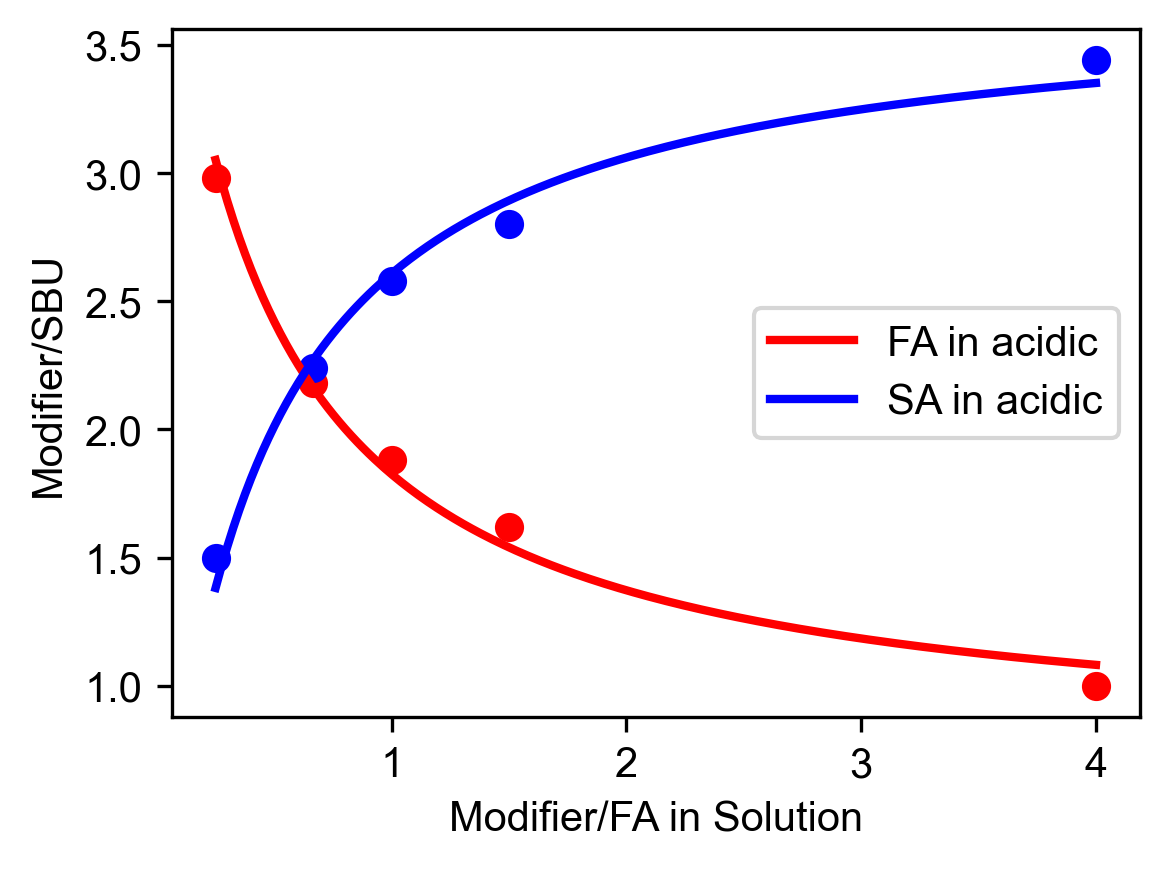

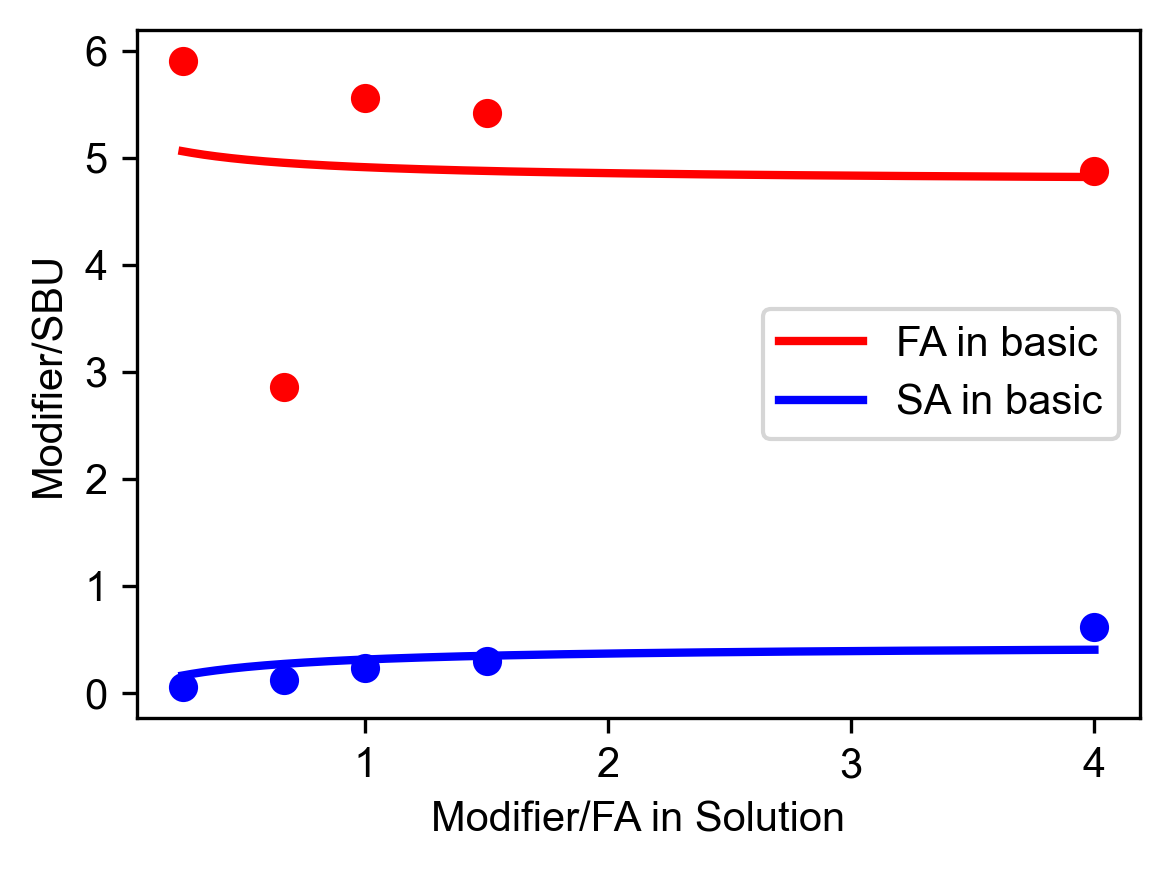

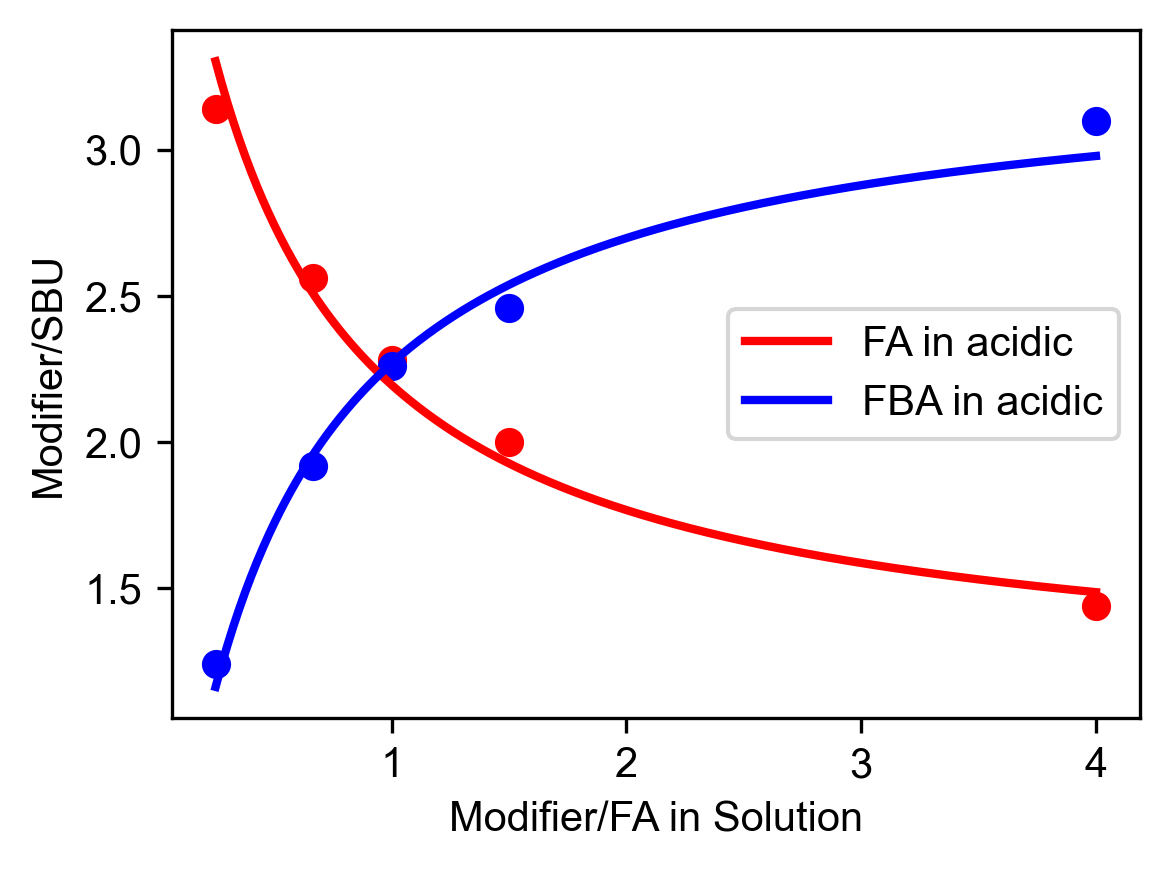

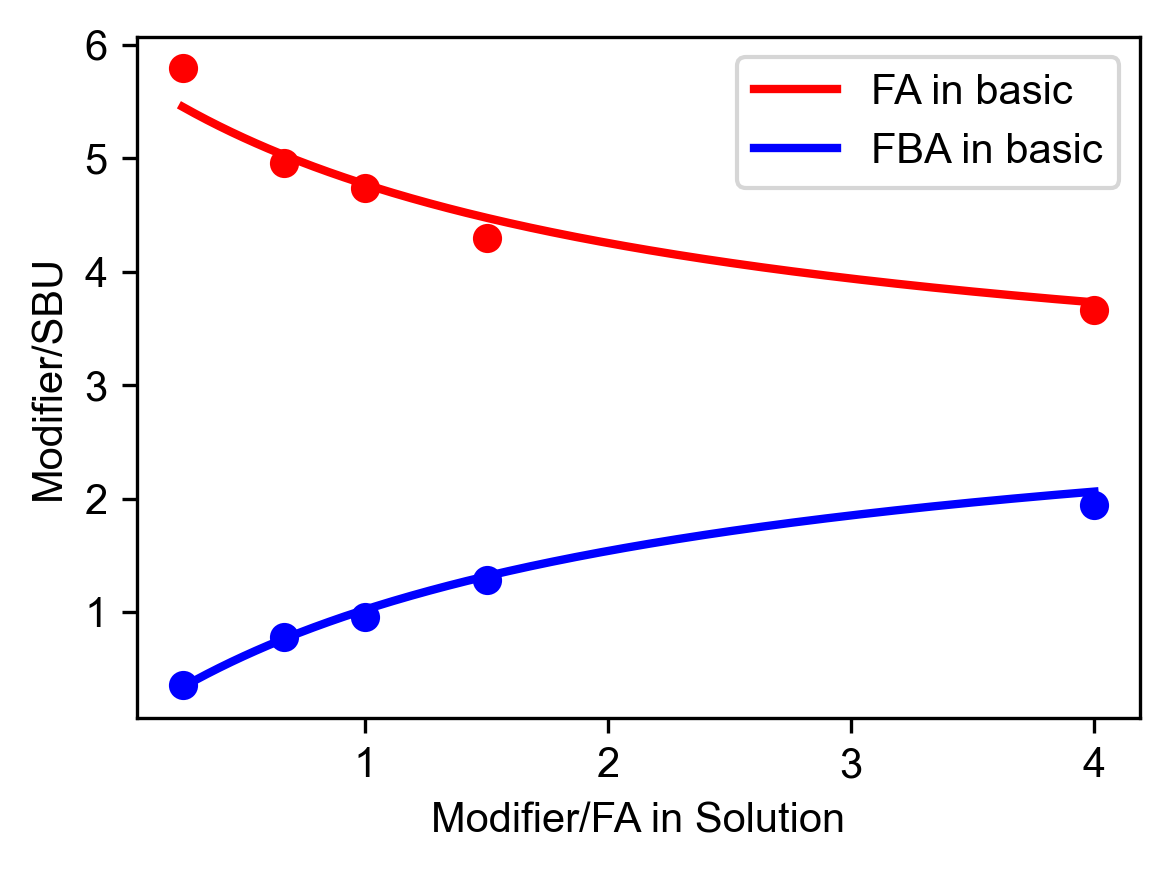

In [9]:
# -----------------------------
# Fit and collect summary
# -----------------------------
summary = []
unique_acid = df["Acid"].unique()

for acid_temp in unique_acid:
    df_by_acid = df[df["Acid"] == acid_temp]
    for experiment_type in df_by_acid["Experiment"].unique():
        try:
            this_curve = df_by_acid[df_by_acid["Experiment"] == experiment_type]
            x = this_curve["Acid conc (mM)"] / this_curve["FA conc (mM)"]
            y1 = this_curve["FA/SBU"].values
            y2 = this_curve["acid/SBU"].values

            popt, pcov = fit_two_curves_shared(x, y1, x, y2, p0=(3., 3.0, 10.), bounds=([0, 0, 0], [12, 12, np.inf]))

            x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 300)
            y_fit = _two_curve_model(np.concatenate((x_fit, x_fit)), len(x_fit), *popt)

            fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)
            ax.plot(x_fit, y_fit[:len(x_fit)], label=f"FA in {experiment_type}", linewidth=2, color = "red")
            ax.plot(x_fit, y_fit[len(x_fit):], label=f"{acid_temp} in {experiment_type}", linewidth=2, color = "blue")
            
            ax.scatter(x, y1, color = "red")
            ax.scatter(x, y2, color = "blue")
            
            ax.set_xlabel(f'Modifier/FA in Solution')
            ax.set_ylabel(f'Modifier/SBU')
            ax.legend(loc='upper left')
            
            ax.legend()
            plt.tight_layout()
            plt.show()

            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "A": popt[0],
                "B": popt[1],
                "k": popt[2]
            })

        except Exception as e:
            print(acid_temp, experiment_type)
            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "Error": str(e)
            })

summary_df = pd.DataFrame(summary)

In [10]:
display(summary1)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,BA,acidic,"[3.52, 3.52, 3.66, 3.56, 3.34]",3.52,0.10,"[0.62, 0.62, 0.64, 0.62, 0.58]",0.62,0.02,0.850999,1.913558
1,BA,basic,"[3.74, 3.7, 4.0, 4.18, 4.07]",3.94,0.19,"[1.84, 1.82, 1.98, 2.06, 2.01]",1.94,0.09,0.669594,0.853338
2,HAc,acidic,"[3.75, 3.78, 3.79, 3.7, 3.8]",3.77,0.04,"[0.65, 0.66, 0.66, 0.64, 0.66]",0.65,0.01,0.852414,1.106587
3,HAc,basic,"[5.74, 5.75, 5.84, 5.81, 6.28]",5.88,0.20,"[-0.03, -0.03, -0.03, -0.03, -0.03]",-0.03,0.00,1.005179,0.630619
4,GA,acidic,"[5.44, 5.33, 5.15, 5.1, 4.69]",5.14,0.26,"[0.18, 0.17, 0.17, 0.17, 0.15]",0.17,0.01,0.968311,9.343682
5,GA,basic,"[6.29, 6.2, 6.18, 6.26, 6.13]",6.21,0.05,"[0.6, 0.6, 0.6, 0.6, 0.59]",0.60,0.01,0.912209,7.350028
6,SA,acidic,"[3.88, 3.87, 3.9, 3.87, 3.92]",3.89,0.02,"[0.56, 0.55, 0.56, 0.55, 0.56]",0.56,0.00,0.874442,1.916102
7,SA,basic,"[1.37, 1.42, 1.44, 0.74, 1.48]",1.29,0.28,"[4.13, 4.3, 4.36, 2.24, 4.48]",3.90,0.84,0.248276,0.205040
8,FBA,acidic,"[3.53, 3.46, 3.53, 3.48, 3.4]",3.48,0.05,"[1.01, 1.0, 1.01, 1.0, 0.98]",1.00,0.01,0.776584,1.777110
9,FBA,basic,"[2.87, 2.86, 2.92, 2.94, 3.16]",2.95,0.11,"[2.73, 2.72, 2.78, 2.8, 3.0]",2.80,0.10,0.512818,0.521948


In [11]:
display(summary_df)

,Acid,Experiment,A,B,k
0,BA,acidic,3.471845,6.644410e-01,2.057493
1,BA,basic,3.923663,1.949649e+00,0.851255
2,HAc,acidic,3.728326,6.868656e-01,1.140774
3,HAc,basic,5.898896,6.260400e-26,0.626309
4,GA,acidic,5.323505,2.319539e-15,7.050719
5,GA,basic,6.041206,7.670950e-01,10.513587
6,SA,acidic,3.703244,7.302029e-01,2.381686
7,SA,basic,0.450420,4.776285e+00,2.338622
8,FBA,acidic,3.324946,1.141151e+00,2.152421
9,FBA,basic,3.124371,2.668088e+00,0.485514


In [12]:
# get rid of the last two messy points 

# summary_df = summary_df.iloc[:-2]
# summary1 = summary1.iloc[:-2]

In [13]:
# Save the summary dataframe to a CSV file
summary_df.to_csv('summary_data.csv', index=False)
print(f"Summary data saved to 'summary_data.csv'")


Summary data saved to 'summary_data.csv'


In [14]:
df[(df['Acid'] == "TFA") & (df['Experiment'] == "basic")]

,Acid,Experiment,Acid conc (mM),FA conc (mM),acid/SBU,FA/SBU


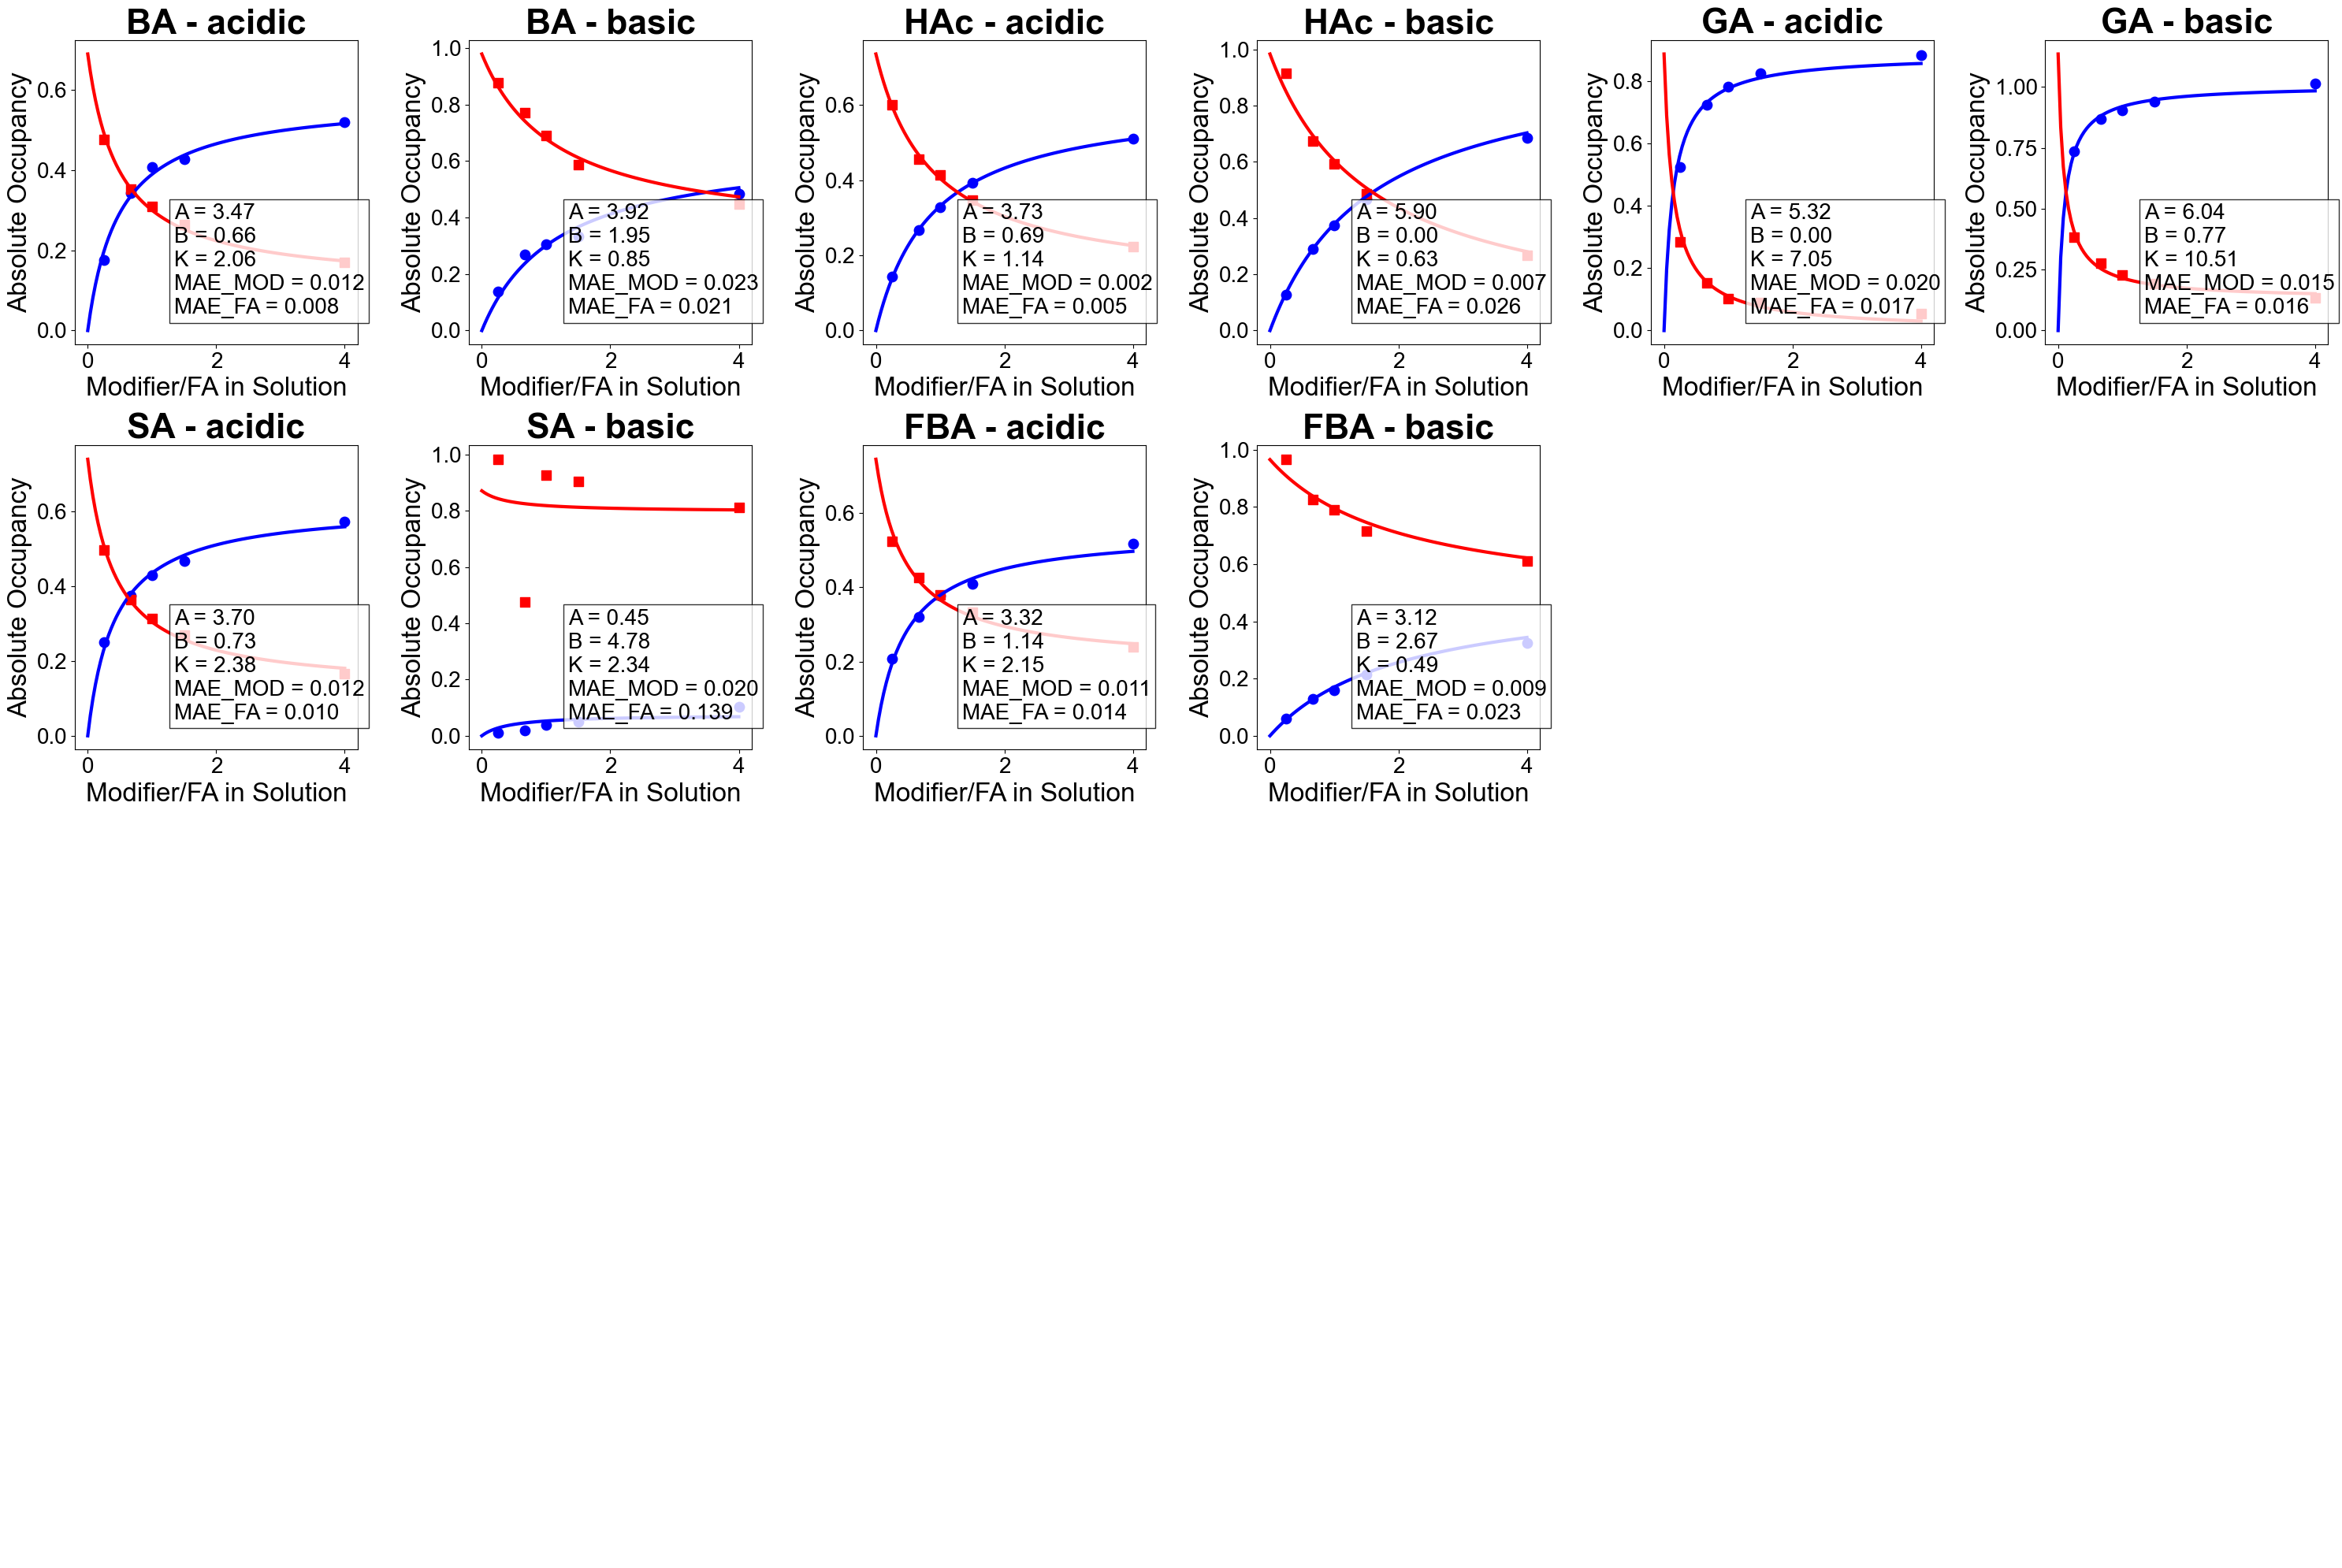

In [15]:
# Create a large plot of the two-curve fitting results for ratio fitting
fig, axes = plt.subplots(4, 6, figsize=(30, 20))
axes = axes.flatten()

# Get the data from summary_df
acids = summary_df['Acid'].unique()

# Counter for subplot position
plot_idx = 0

# Define legend elements for reuse across all subplots
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

for acid in acids:
    acid_data = summary_df[summary_df['Acid'] == acid]
    
    if acid == 'BMH':
        continue
        
    for _, row in acid_data.iterrows():
        if plot_idx >= len(axes):
            break
            
        ax = axes[plot_idx]
        
        try:
            A = row['A']
            B = row['B']
            k = row['k']
            experiment_type = row['Experiment']
            
            exp_data = df[(df['Acid'] == acid) & (df['Experiment'] == experiment_type)]
            
            if not exp_data.empty:
                x_exp = exp_data['Acid conc (mM)'].values / exp_data['FA conc (mM)'].values
                y_exp_modifier = exp_data['acid/SBU'].values / 6
                y_exp_formate  = exp_data['FA/SBU'].values / 6

                ax.scatter(x_exp, y_exp_modifier, color='blue', marker='o', s=80)
                ax.scatter(x_exp, y_exp_formate,  color='red', marker='s', s=80)
                
                x_fit = np.linspace(0, 4, 100)
                xcat = np.concatenate((x_fit, x_fit))
                n1 = len(x_fit)
                y_fit = _two_curve_model(xcat, n1, A, B, k) / 6
                y_fit_formate, y_fit_modifier = y_fit[:n1], y_fit[n1:]
                
                ax.plot(x_fit, y_fit_modifier, 'b-', linewidth=3.0)
                ax.plot(x_fit, y_fit_formate, 'r-', linewidth=3.0)
                
                # ---- Compute residuals and R² ----
                y_pred_modifier = np.interp(x_exp, x_fit, y_fit_modifier)
                y_pred_formate  = np.interp(x_exp, x_fit, y_fit_formate)

                residual_modifier = abs(y_exp_modifier - y_pred_modifier)
                residual_formate  = abs(y_exp_formate - y_pred_formate)

                ss_res_mod = np.sum(residual_modifier**2)
                ss_tot_mod = np.sum((y_exp_modifier - np.mean(y_exp_modifier))**2)
                r2_modifier = 1 - ss_res_mod/ss_tot_mod if ss_tot_mod != 0 else np.nan

                ss_res_for = np.sum(residual_formate**2)
                ss_tot_for = np.sum((y_exp_formate - np.mean(y_exp_formate))**2)
                r2_formate = 1 - ss_res_for/ss_tot_for if ss_tot_for != 0 else np.nan

                # ---- Store residuals and R² values in summary_df ----
                summary_df.loc[row.name, 'Residual Modifier'] = residual_modifier.mean()  # Store mean residuals
                summary_df.loc[row.name, 'Residual Formate'] = residual_formate.mean()      # Store mean residuals
                summary_df.loc[row.name, 'R² Modifier'] = r2_modifier
                summary_df.loc[row.name, 'R² Formate'] = r2_formate

                # ---- Add results as text on the plot ----
                k_text = f"{k:.2e}" if k > 1000 else f"{k:.2f}"
                param_text = (
                    f"A = {A:.2f}\n"
                    f"B = {B:.2f}\n"
                    f"K = {k_text}\n"
                    f"MAE_MOD = {residual_modifier.mean():.3f}\n"
                    f"MAE_FA = {residual_formate.mean():.3f}"
                )
                ax.text(0.35, 0.10, param_text, transform=ax.transAxes,
                        bbox=dict(facecolor='white', alpha=0.8), fontsize=20)
                
            ax.set_title(f"{acid} - {experiment_type}", fontsize=32, fontweight='bold')
            ax.set_xlabel('Modifier/FA in Solution', fontsize=24)
            ax.set_ylabel('Absolute Occupancy', fontsize=24)
            ax.tick_params(axis='both', which='major', labelsize=20)

            plot_idx += 1
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=ax.transAxes, fontsize=14)
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [16]:
acids

array(['BA', 'HAc', 'GA', 'SA', 'FBA'], dtype=object)

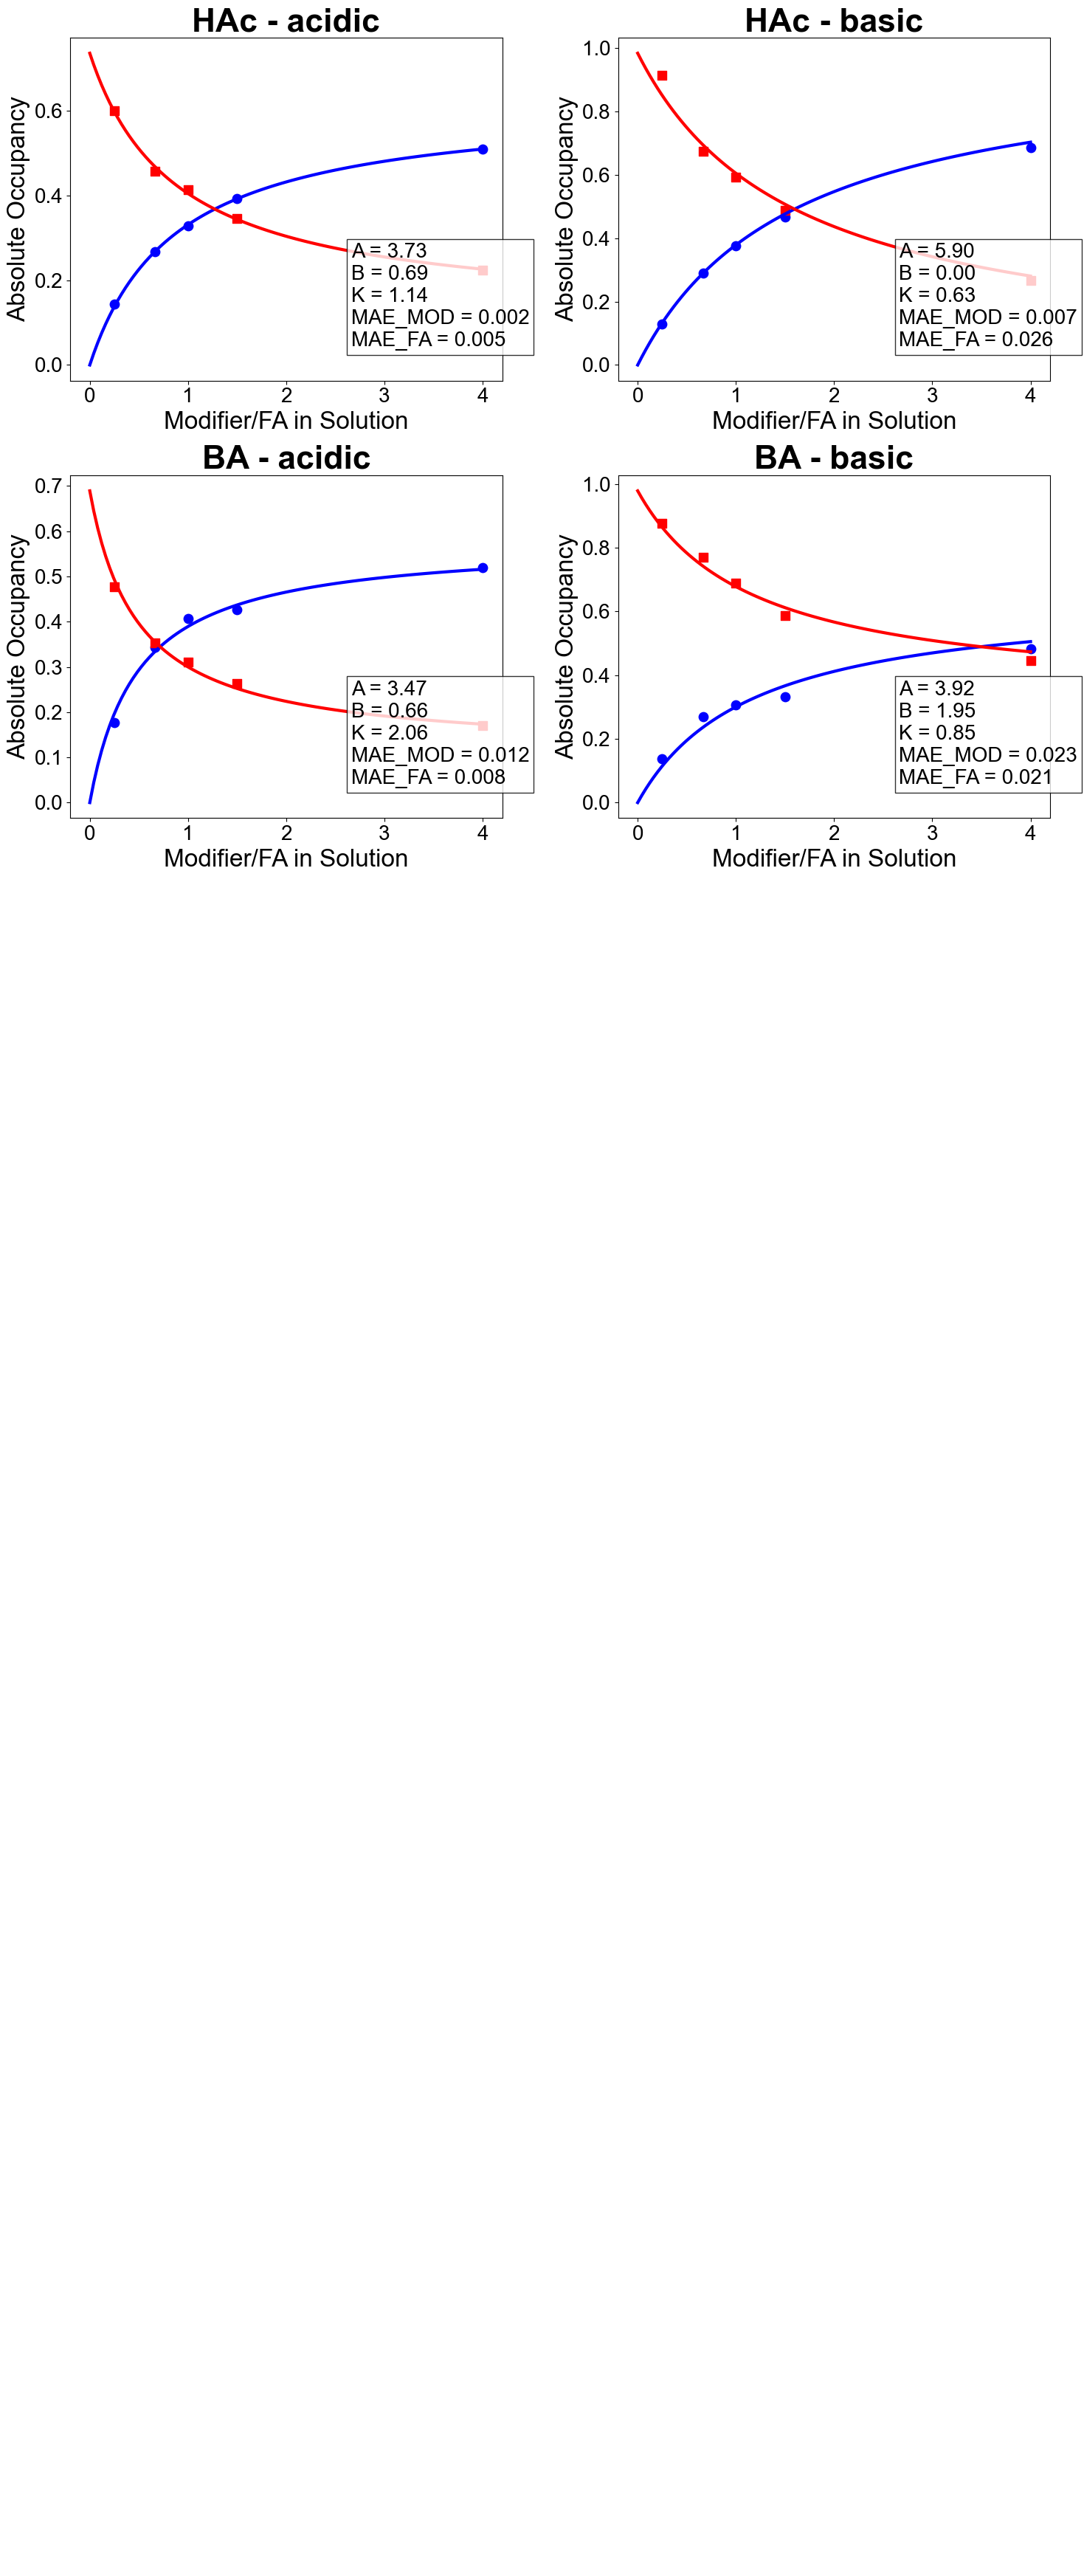

In [17]:
# Create a large plot of the two-curve fitting results for ratio fitting
fig, axes = plt.subplots(6, 2, figsize=(15, 35))
axes = axes.flatten()

# Get the data from summary_df
acids = ["TFA", "TA", "HAc", "BA", "MA", "PA", "CA"]

# Counter for subplot position
plot_idx = 0

# Define legend elements for reuse across all subplots
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

for acid in acids:
    acid_data = summary_df[summary_df['Acid'] == acid]
    
    if acid == 'BMH':
        continue
        
    for _, row in acid_data.iterrows():
        if plot_idx >= len(axes):
            break
            
        ax = axes[plot_idx]
        
        try:
            A = row['A']
            B = row['B']
            k = row['k']
            experiment_type = row['Experiment']
            
            exp_data = df[(df['Acid'] == acid) & (df['Experiment'] == experiment_type)]
            
            if not exp_data.empty:
                x_exp = exp_data['Acid conc (mM)'].values / exp_data['FA conc (mM)'].values
                y_exp_modifier = exp_data['acid/SBU'].values / 6
                y_exp_formate  = exp_data['FA/SBU'].values / 6

                ax.scatter(x_exp, y_exp_modifier, color='blue', marker='o', s=80)
                ax.scatter(x_exp, y_exp_formate,  color='red', marker='s', s=80)
                
                x_fit = np.linspace(0, 4, 100)
                xcat = np.concatenate((x_fit, x_fit))
                n1 = len(x_fit)
                y_fit = _two_curve_model(xcat, n1, A, B, k) / 6
                y_fit_formate, y_fit_modifier = y_fit[:n1], y_fit[n1:]
                
                ax.plot(x_fit, y_fit_modifier, 'b-', linewidth=3.0)
                ax.plot(x_fit, y_fit_formate, 'r-', linewidth=3.0)
                
                # ---- Compute residuals and R² ----
                y_pred_modifier = np.interp(x_exp, x_fit, y_fit_modifier)
                y_pred_formate  = np.interp(x_exp, x_fit, y_fit_formate)

                residual_modifier = abs(y_exp_modifier - y_pred_modifier)
                residual_formate  = abs(y_exp_formate - y_pred_formate)

                ss_res_mod = np.sum(residual_modifier**2)
                ss_tot_mod = np.sum((y_exp_modifier - np.mean(y_exp_modifier))**2)
                r2_modifier = 1 - ss_res_mod/ss_tot_mod if ss_tot_mod != 0 else np.nan

                ss_res_for = np.sum(residual_formate**2)
                ss_tot_for = np.sum((y_exp_formate - np.mean(y_exp_formate))**2)
                r2_formate = 1 - ss_res_for/ss_tot_for if ss_tot_for != 0 else np.nan

                # ---- Store residuals and R² values in summary_df ----
                summary_df.loc[row.name, 'Residual Modifier'] = residual_modifier.mean()  # Store mean residuals
                summary_df.loc[row.name, 'Residual Formate'] = residual_formate.mean()      # Store mean residuals
                summary_df.loc[row.name, 'R² Modifier'] = r2_modifier
                summary_df.loc[row.name, 'R² Formate'] = r2_formate

                # ---- Add results as text on the plot ----
                k_text = f"{k:.2e}" if k > 1000 else f"{k:.2f}"
                param_text = (
                    f"A = {A:.2f}\n"
                    f"B = {B:.2f}\n"
                    f"K = {k_text}\n"
                    f"MAE_MOD = {residual_modifier.mean():.3f}\n"
                    f"MAE_FA = {residual_formate.mean():.3f}"
                )
                ax.text(0.65, 0.10, param_text, transform=ax.transAxes,
                        bbox=dict(facecolor='white', alpha=0.8), fontsize=20)
                
            ax.set_title(f"{acid} - {experiment_type}", fontsize=32, fontweight='bold')
            ax.set_xlabel('Modifier/FA in Solution', fontsize=24)
            ax.set_ylabel('Absolute Occupancy', fontsize=24)
            ax.tick_params(axis='both', which='major', labelsize=20)

            plot_idx += 1
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=ax.transAxes, fontsize=14)
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


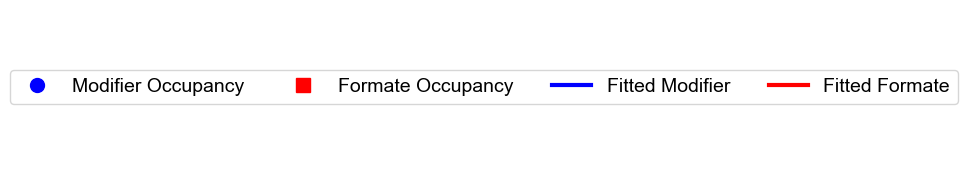

In [18]:
import matplotlib.pyplot as plt

# Define legend elements
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

# Create a new figure for the legend
fig = plt.figure(figsize=(6, 2))

# Plot the legend alone
plt.legend(handles=legend_elements, loc='center', fontsize=14, ncol=4)

# Hide axes and ticks since it's just a legend
plt.axis('off')

# Display the figure with the legend
plt.show()


In [19]:
summary1 = summary1[summary1["Acid"] != "BMH"].reindex()
summary_df = summary_df[summary_df["Acid"] != "BMH"].reindex()

In [20]:
display(summary1)
display(summary_df)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,BA,acidic,"[3.52, 3.52, 3.66, 3.56, 3.34]",3.52,0.10,"[0.62, 0.62, 0.64, 0.62, 0.58]",0.62,0.02,0.850999,1.913558
1,BA,basic,"[3.74, 3.7, 4.0, 4.18, 4.07]",3.94,0.19,"[1.84, 1.82, 1.98, 2.06, 2.01]",1.94,0.09,0.669594,0.853338
2,HAc,acidic,"[3.75, 3.78, 3.79, 3.7, 3.8]",3.77,0.04,"[0.65, 0.66, 0.66, 0.64, 0.66]",0.65,0.01,0.852414,1.106587
3,HAc,basic,"[5.74, 5.75, 5.84, 5.81, 6.28]",5.88,0.20,"[-0.03, -0.03, -0.03, -0.03, -0.03]",-0.03,0.00,1.005179,0.630619
4,GA,acidic,"[5.44, 5.33, 5.15, 5.1, 4.69]",5.14,0.26,"[0.18, 0.17, 0.17, 0.17, 0.15]",0.17,0.01,0.968311,9.343682
5,GA,basic,"[6.29, 6.2, 6.18, 6.26, 6.13]",6.21,0.05,"[0.6, 0.6, 0.6, 0.6, 0.59]",0.60,0.01,0.912209,7.350028
6,SA,acidic,"[3.88, 3.87, 3.9, 3.87, 3.92]",3.89,0.02,"[0.56, 0.55, 0.56, 0.55, 0.56]",0.56,0.00,0.874442,1.916102
7,SA,basic,"[1.37, 1.42, 1.44, 0.74, 1.48]",1.29,0.28,"[4.13, 4.3, 4.36, 2.24, 4.48]",3.90,0.84,0.248276,0.205040
8,FBA,acidic,"[3.53, 3.46, 3.53, 3.48, 3.4]",3.48,0.05,"[1.01, 1.0, 1.01, 1.0, 0.98]",1.00,0.01,0.776584,1.777110
9,FBA,basic,"[2.87, 2.86, 2.92, 2.94, 3.16]",2.95,0.11,"[2.73, 2.72, 2.78, 2.8, 3.0]",2.80,0.10,0.512818,0.521948


,Acid,Experiment,A,B,k,Residual Modifier,Residual Formate,R² Modifier,R² Formate
0,BA,acidic,3.471845,6.644410e-01,2.057493,0.012034,0.008439,0.986345,0.990236
1,BA,basic,3.923663,1.949649e+00,0.851255,0.023363,0.020860,0.947982,0.977855
2,HAc,acidic,3.728326,6.868656e-01,1.140774,0.002293,0.005431,0.999434,0.997259
3,HAc,basic,5.898896,6.260400e-26,0.626309,0.007198,0.025760,0.997443,0.977343
4,GA,acidic,5.323505,2.319539e-15,7.050719,0.019526,0.016784,0.963160,0.930480
5,GA,basic,6.041206,7.670950e-01,10.513587,0.015327,0.016051,0.962991,0.957371
6,SA,acidic,3.703244,7.302029e-01,2.381686,0.012024,0.010243,0.984104,0.989813
7,SA,basic,0.450420,4.776285e+00,2.338622,0.019982,0.139482,0.535211,0.010648
8,FBA,acidic,3.324946,1.141151e+00,2.152421,0.010884,0.014014,0.984845,0.972415
9,FBA,basic,3.124371,2.668088e+00,0.485514,0.008603,0.023051,0.985162,0.936131


3. plot comparison of these two models

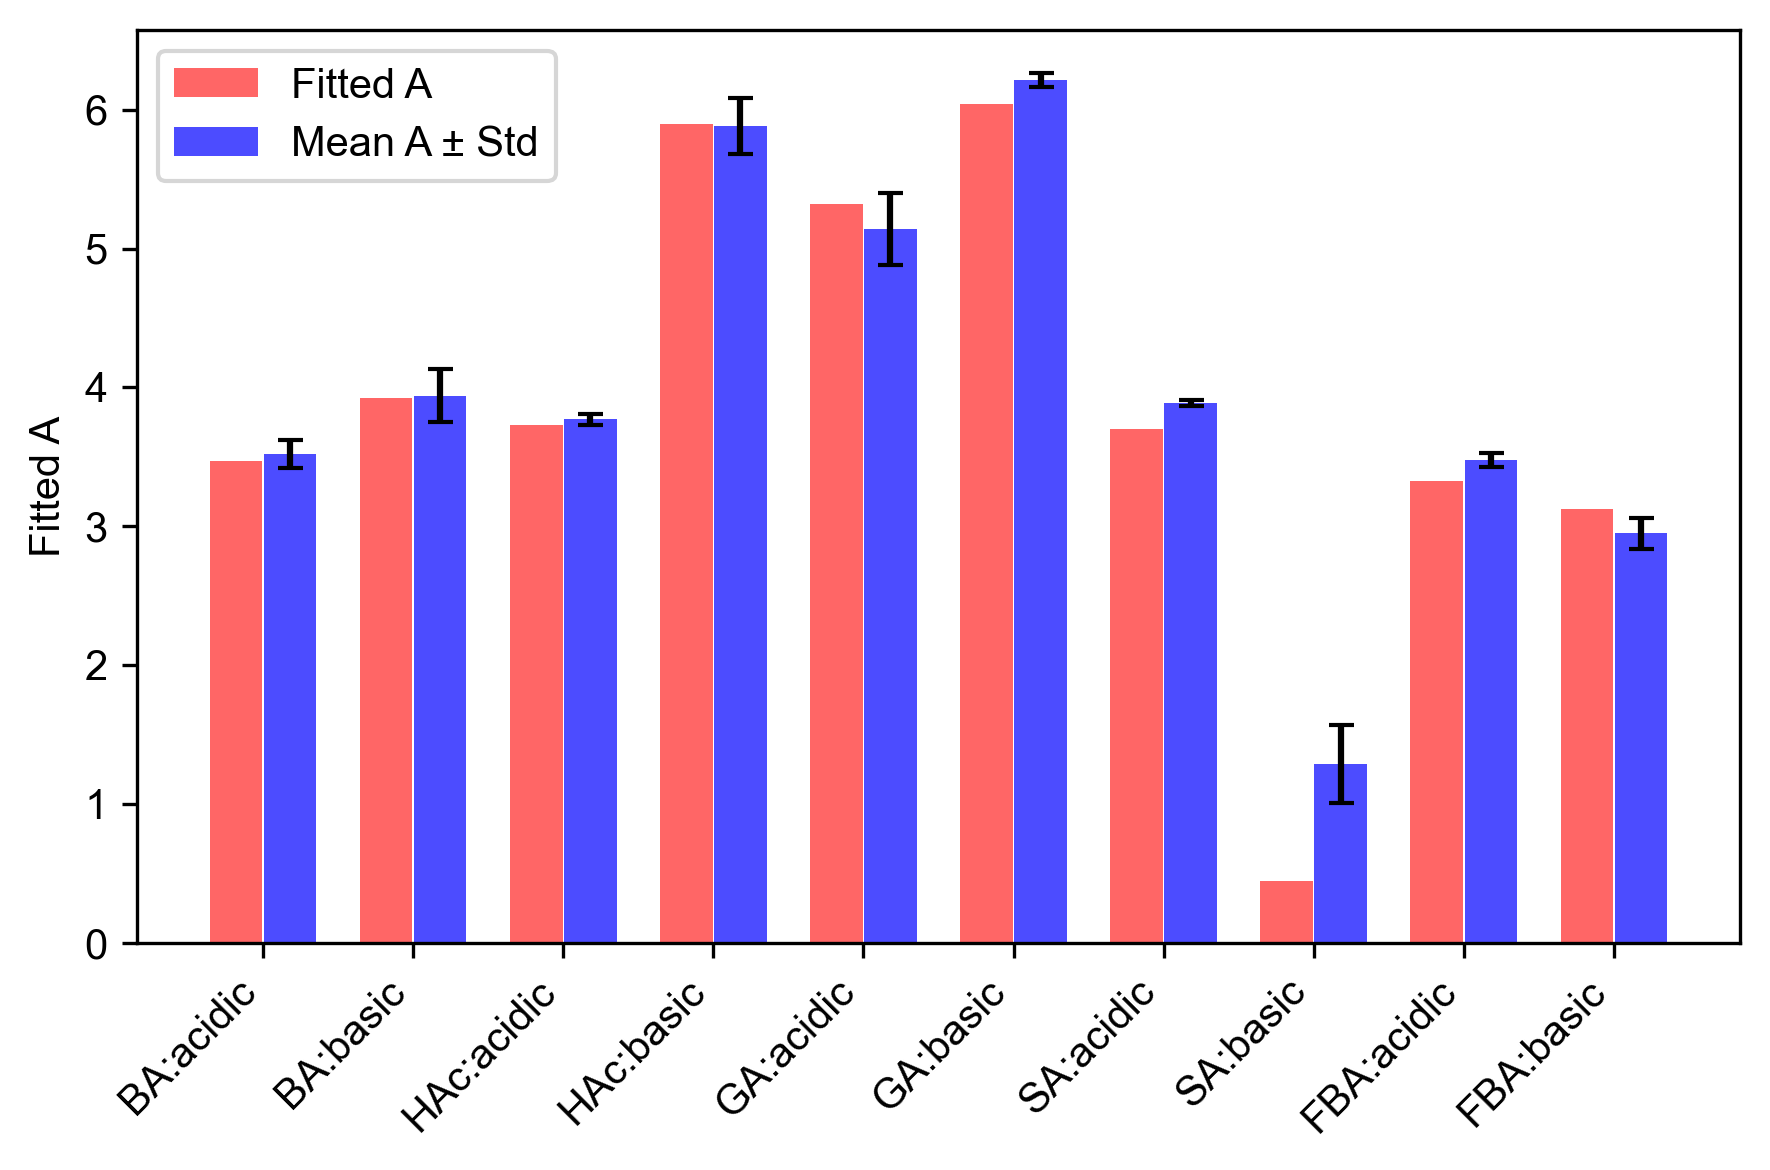

In [21]:
plt.figure(figsize=(6, 4), dpi=300)

# Filter summary_df to only include entries that are in summary1
filtered_df = summary_df[summary_df.index.isin(summary1.index)]

x_pos = np.arange(len(filtered_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    if i < len(filtered_df) - 1:
        plt.bar(x=i - offset, height=row['A'], width=bar_width, color="red", alpha=0.6)
    else:
        plt.bar(x=i - offset, height=row['A'], width=bar_width, color="red", alpha=0.6, label="Fitted A")

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["mean_A"],
    yerr=summary1["std_A"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
    label="Mean A ± Std"
)

# Set x-axis labels
xtick_labels = filtered_df["Acid"] + ":" + filtered_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')
plt.ylabel("Fitted A")
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

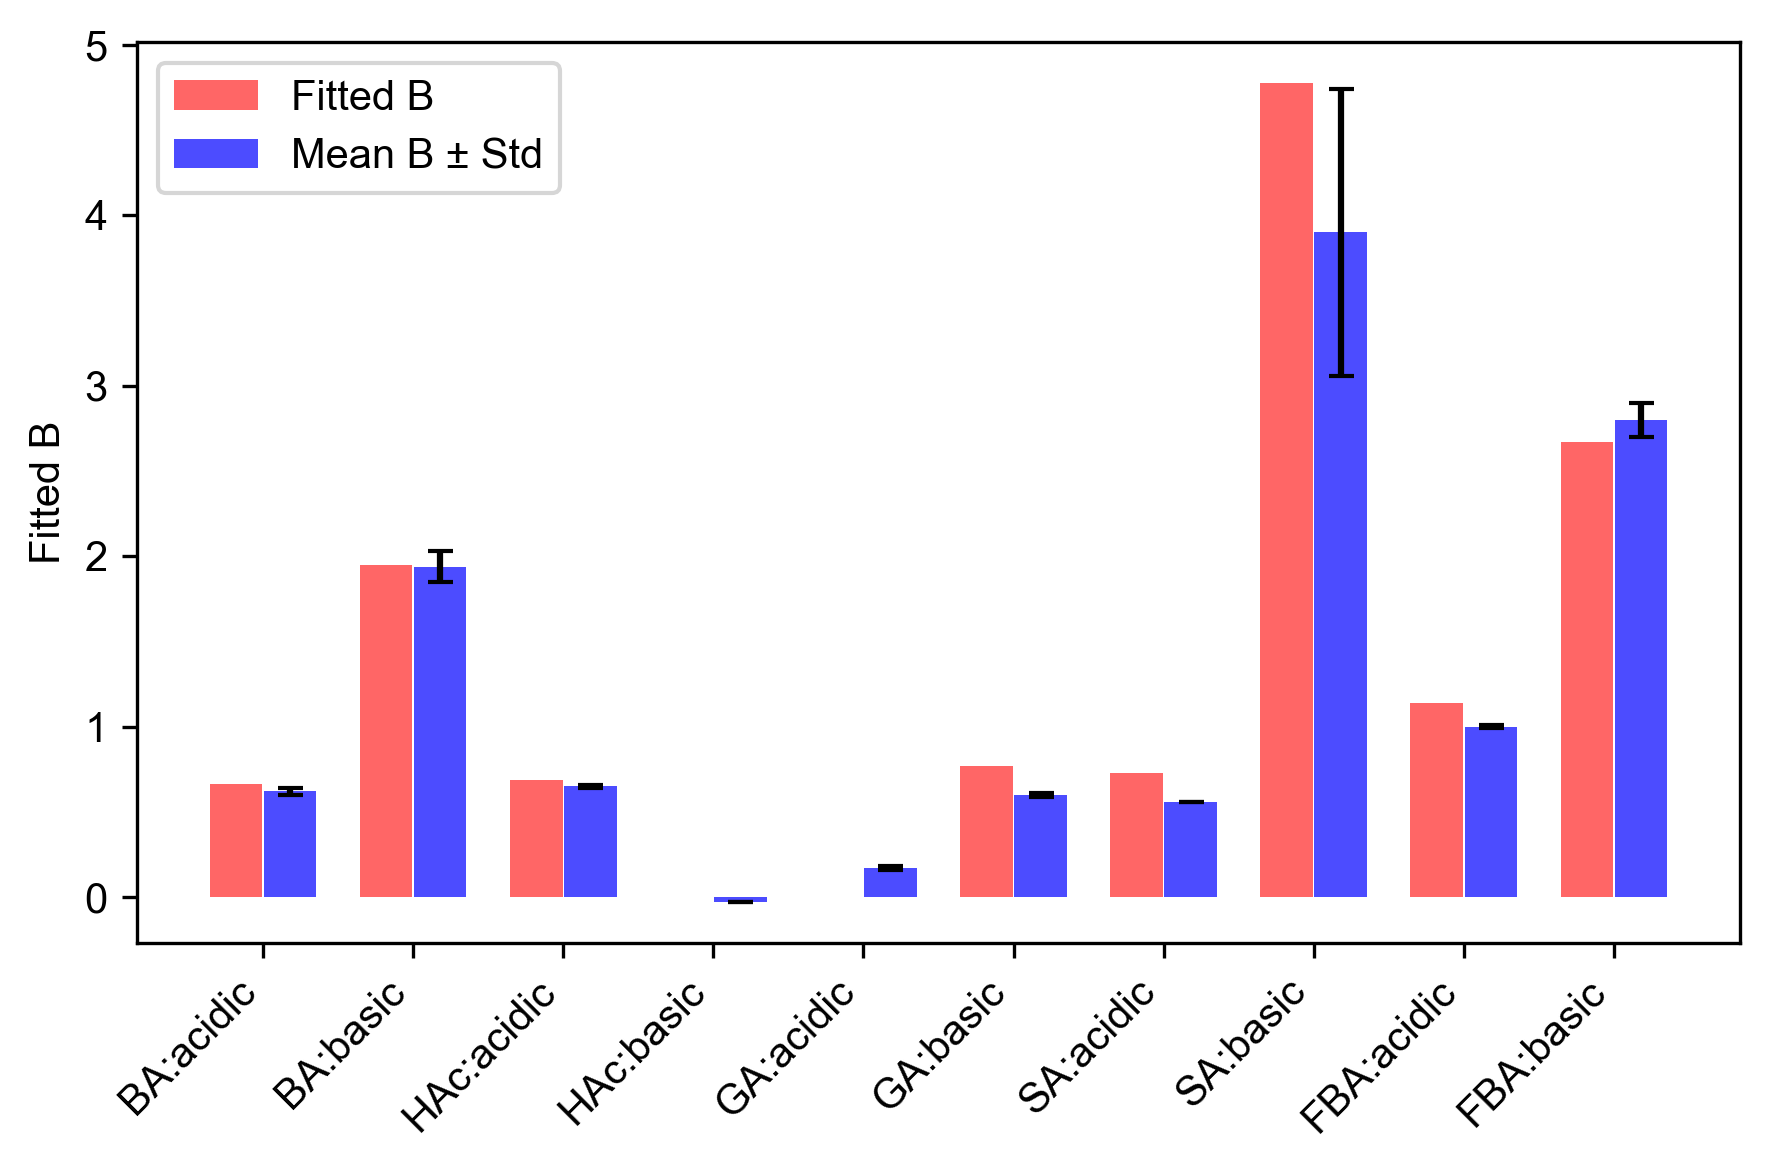

In [22]:
plt.figure(figsize=(6, 4), dpi=300)

# Filter summary_df to only include entries that are in summary1
filtered_df = summary_df[summary_df.index.isin(summary1.index)]

x_pos = np.arange(len(filtered_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    if i < len(filtered_df) - 1:
        plt.bar(x=i - offset, height=row['B'], width=bar_width, color="red", alpha=0.6)
    else:
        plt.bar(x=i - offset, height=row['B'], width=bar_width, color="red", alpha=0.6, label="Fitted B")

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["mean_B"],
    yerr=summary1["std_B"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
    label="Mean B ± Std"
)

# Set x-axis labels
xtick_labels = filtered_df["Acid"] + ":" + filtered_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')
plt.ylabel("Fitted B")
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

In [23]:
summary_df

,Acid,Experiment,A,B,k,Residual Modifier,Residual Formate,R² Modifier,R² Formate
0,BA,acidic,3.471845,6.644410e-01,2.057493,0.012034,0.008439,0.986345,0.990236
1,BA,basic,3.923663,1.949649e+00,0.851255,0.023363,0.020860,0.947982,0.977855
2,HAc,acidic,3.728326,6.868656e-01,1.140774,0.002293,0.005431,0.999434,0.997259
3,HAc,basic,5.898896,6.260400e-26,0.626309,0.007198,0.025760,0.997443,0.977343
4,GA,acidic,5.323505,2.319539e-15,7.050719,0.019526,0.016784,0.963160,0.930480
5,GA,basic,6.041206,7.670950e-01,10.513587,0.015327,0.016051,0.962991,0.957371
6,SA,acidic,3.703244,7.302029e-01,2.381686,0.012024,0.010243,0.984104,0.989813
7,SA,basic,0.450420,4.776285e+00,2.338622,0.019982,0.139482,0.535211,0.010648
8,FBA,acidic,3.324946,1.141151e+00,2.152421,0.010884,0.014014,0.984845,0.972415
9,FBA,basic,3.124371,2.668088e+00,0.485514,0.008603,0.023051,0.985162,0.936131


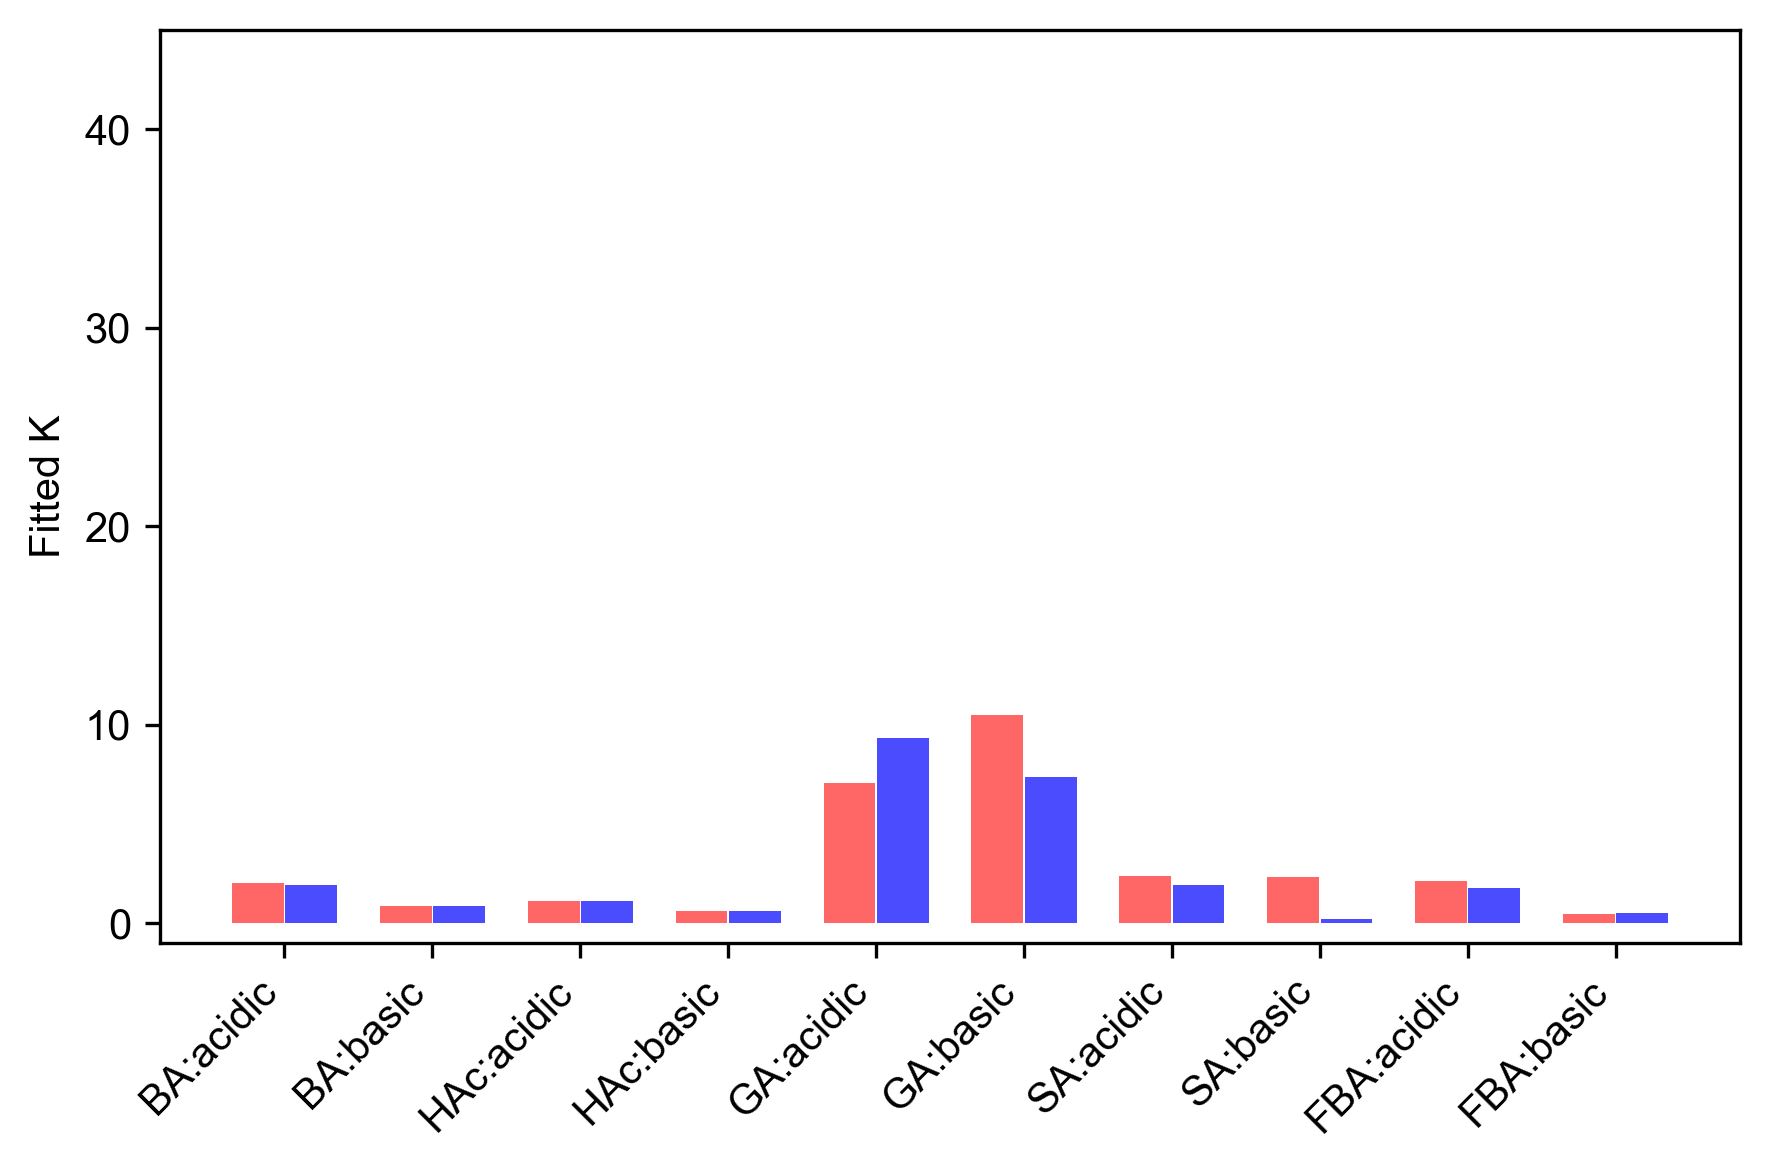

In [24]:
plt.figure(figsize=(6, 4), dpi=300)

x_pos = np.arange(len(summary_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, A_list in enumerate(summary_df["k"].iloc[:-1]):
    a = A_list
    plt.bar(x= i - offset, height=a, width=bar_width, color="red", alpha=0.6)
    
for i, A_list in enumerate(summary_df["k"].iloc[-1:]):
    a = A_list
    i = len(summary_df["k"]) - 1
    plt.bar(x= i - offset, height=a, width=bar_width, color="red", alpha=0.6)

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["k"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
)

# Set x-axis labels
xtick_labels = summary_df["Acid"] + ":" + summary_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')

plt.ylabel("Fitted K")
plt.ylim(-1, 45)
plt.tight_layout()
plt.show()